In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from sklearn.linear_model import LinearRegression
from scipy.stats import kurtosis
from IPython.display import clear_output

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

from scipy.stats import skew


In [6]:
# ─────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────

METADATA_PATH = "Dataset/filtered_metadata.csv"
DATA_PATH     = Path("Dataset/merged_imp_csv")
OUTPUT_DIR    = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Date boundaries — pre / in / post
PERIODS = [
    {
        "suffix": "pre",
        "start":  None,                        # no lower bound
        "end":    "2020-02-29 23:00:00",
    },
    {
        "suffix": "in",
        "start":  "2020-03-01 00:00:00",
        "end":    "2021-05-30 23:00:00",
    },
    {
        "suffix": "post",
        "start":  "2021-05-31 00:00:00",
        "end":    None,                        # no upper bound
    },
]

SLOPE_THRESHOLD = 1e-6
MIN_HOURS       = 24 * 365
MAX_NAN_PCT     = 0.10
MIN_ZIP_USERS     = 150

══════════════════════════════════════════════════
  1 / 4  Seasonality
══════════════════════════════════════════════════
  ✔ [1] Sector 'Household production': 16311 users
  ✔ [2] Sector 'Public administration': 612 users
  ✔ [3] Sector 'Warehousing and logistics': 481 users
  ✔ [4] Sector 'Retail trade': 346 users
  ✔ [5] Sector 'Education': 211 users
  ✔ [6] Sector 'Food and beverage services': 210 users
  ✔ [7] Sector 'Associations': 171 users
  ✔ [8] Sector 'Sports and recreation': 126 users
  ✔ [9] Sector 'Construction (buildings)': 89 users
  ✔ [10] Sector 'Personal services': 82 users
  ✔ [11] Sector 'Other professional services': 80 users
  ✔ [12] Sector 'Wholesale trade': 72 users
  ✔ [13] Sector 'Agriculture, livestock, fishing': 71 users
  ✔ [14] Sector 'Water supply': 53 users
  ✔ [15] Sector 'Accommodation': 45 users
  ✔ [16] Sector 'Real estate': 45 users
  ✔ [17] Sector 'Healthcare': 44 users
  ✔ [18] Sector 'Specialized construction': 37 users
  ✔ [19] Sector 'Vehicle

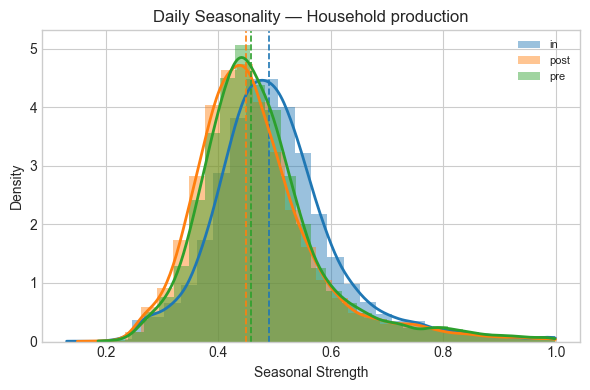

  ✔ Figure saved → results\figures\1a_household_production_weekly.png


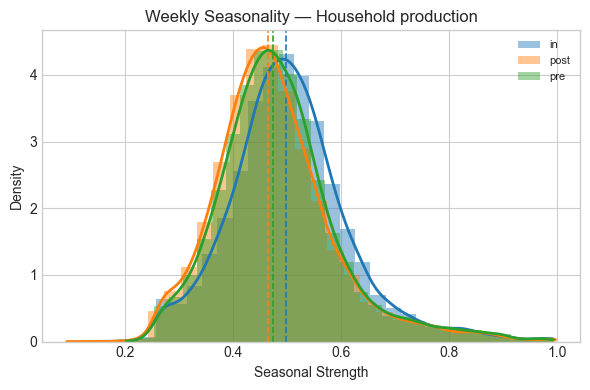

  ✔ Figure saved → results\figures\1a_household_production_compare.png


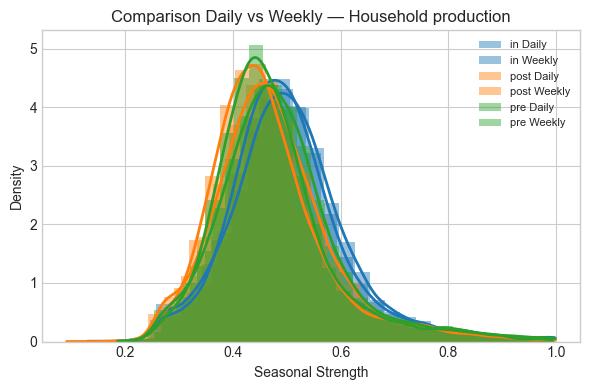

  ✔ Figure saved → results\figures\1b_household_production_boxplot.png


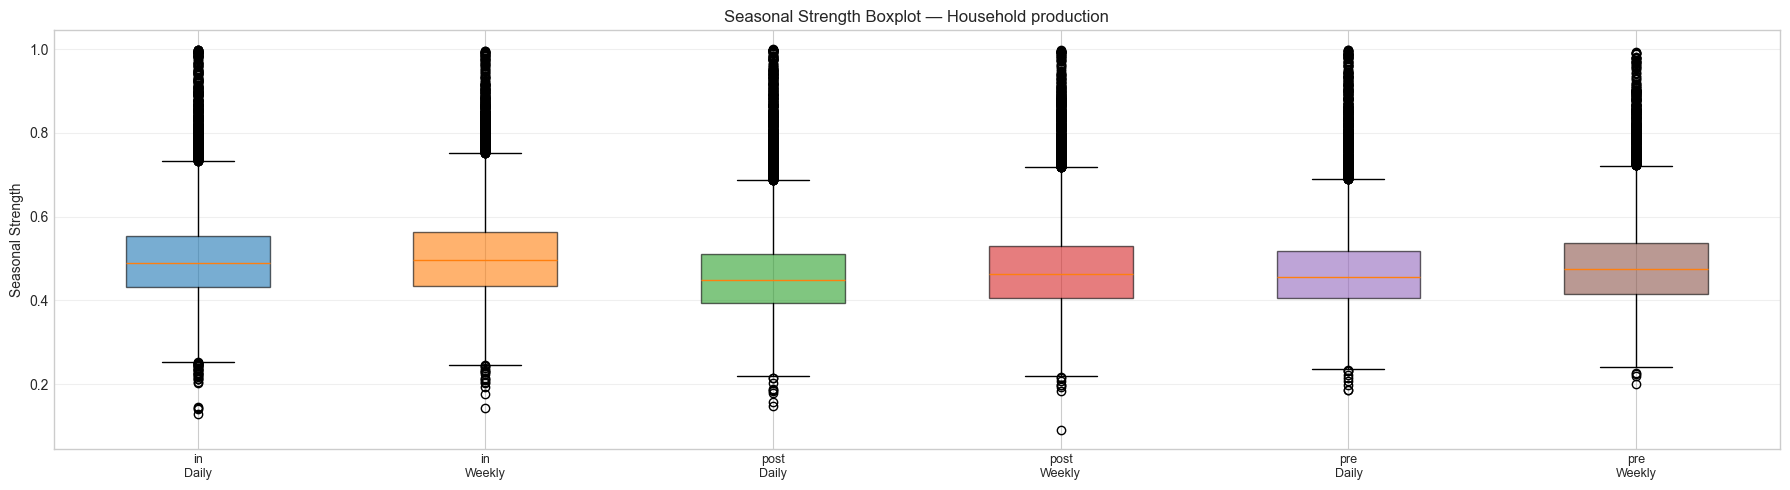


  ┌──────────────────────────────────────────────────────────────────────┐
  │  Seasonality Daily — Household production                            │
  └──────────────────────────────────────────────────────────────────────┘
          N      Mean    Median       Std       Min       P25       P75       Max  Skewness
in    12689  0.500922  0.489472  0.111751  0.130007  0.432709  0.552897  0.998948  0.969510
post  14304  0.465746  0.448255  0.112115  0.149108  0.394752  0.512051  0.999228  1.350746
pre    9730  0.475907  0.457177  0.113113  0.185731  0.405679  0.519302  0.997992  1.418535

  ✔ Table saved → results\tables\T1_household_production_seasonality_daily.csv

  ┌──────────────────────────────────────────────────────────────────────┐
  │  Seasonality Weekly — Household production                           │
  └──────────────────────────────────────────────────────────────────────┘
          N      Mean    Median       Std       Min       P25       P75       Max  Skewness
in    12

C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))


  ✔ Figure saved → results\figures\1a_public_administration_daily.png


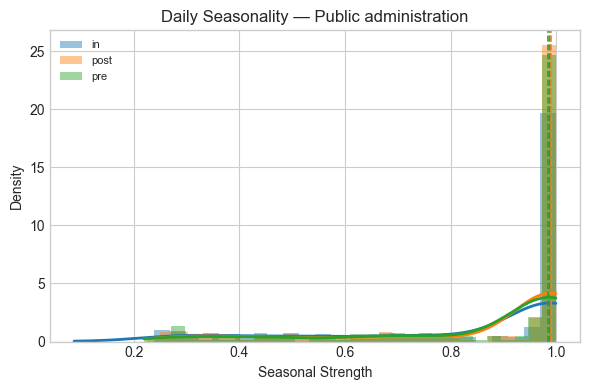

  ✔ Figure saved → results\figures\1a_public_administration_weekly.png


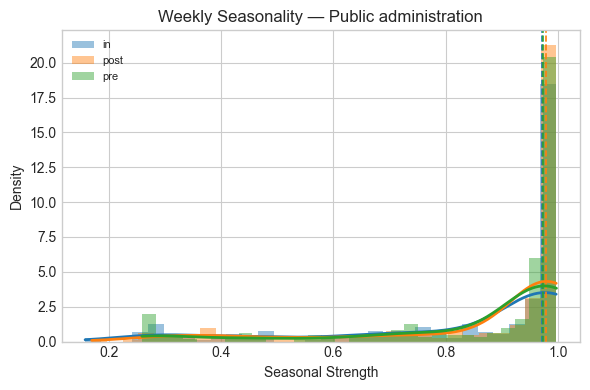

  ✔ Figure saved → results\figures\1a_public_administration_compare.png


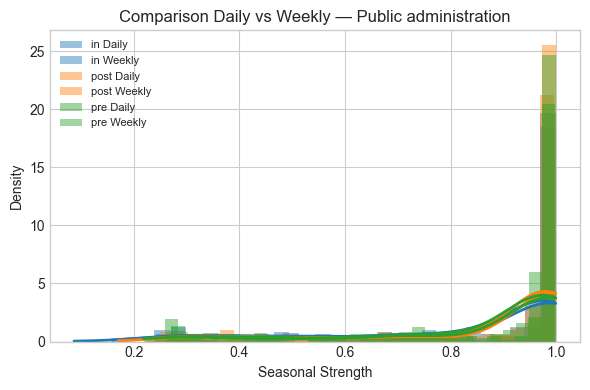

  ✔ Figure saved → results\figures\1b_public_administration_boxplot.png


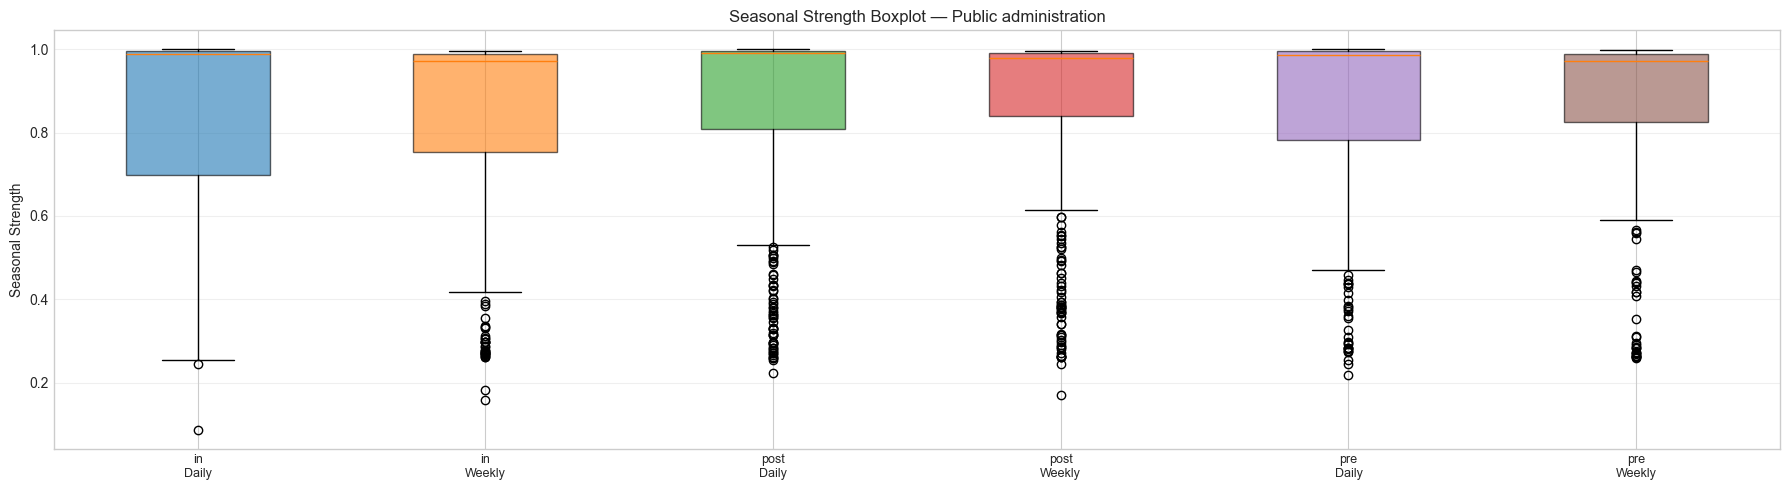


  ┌──────────────────────────────────────────────────────────────────────┐
  │  Seasonality Daily — Public administration                           │
  └──────────────────────────────────────────────────────────────────────┘
        N      Mean    Median       Std       Min       P25       P75       Max  Skewness
in    317  0.831426  0.987801  0.248081  0.086470  0.699144  0.995820  0.999519 -1.254337
post  396  0.865141  0.990069  0.227609  0.224199  0.809730  0.996362  0.999613 -1.563550
pre   251  0.862576  0.985355  0.224754  0.218588  0.781935  0.994827  0.999635 -1.577629

  ✔ Table saved → results\tables\T1_public_administration_seasonality_daily.csv

  ┌──────────────────────────────────────────────────────────────────────┐
  │  Seasonality Weekly — Public administration                          │
  └──────────────────────────────────────────────────────────────────────┘
        N      Mean    Median       Std       Min       P25       P75       Max  Skewness
in    317  0.8378

C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))


  ✔ Figure saved → results\figures\2a_household_production_trend_slope_distributions_merged.png


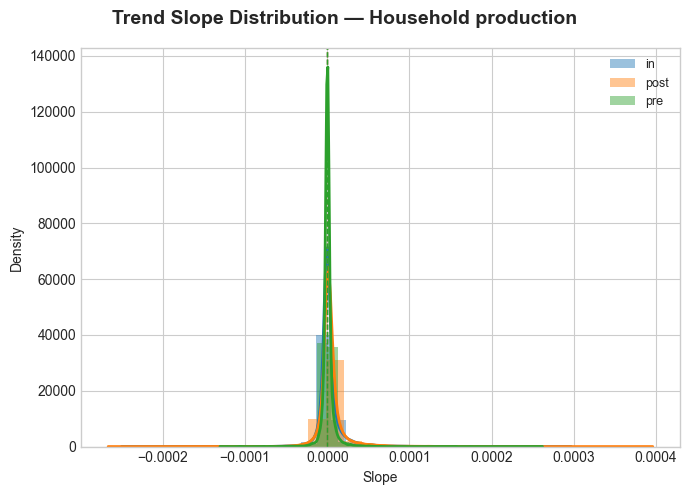

  ✔ Figure saved → results\figures\2b_household_production_trend_categories_bar.png


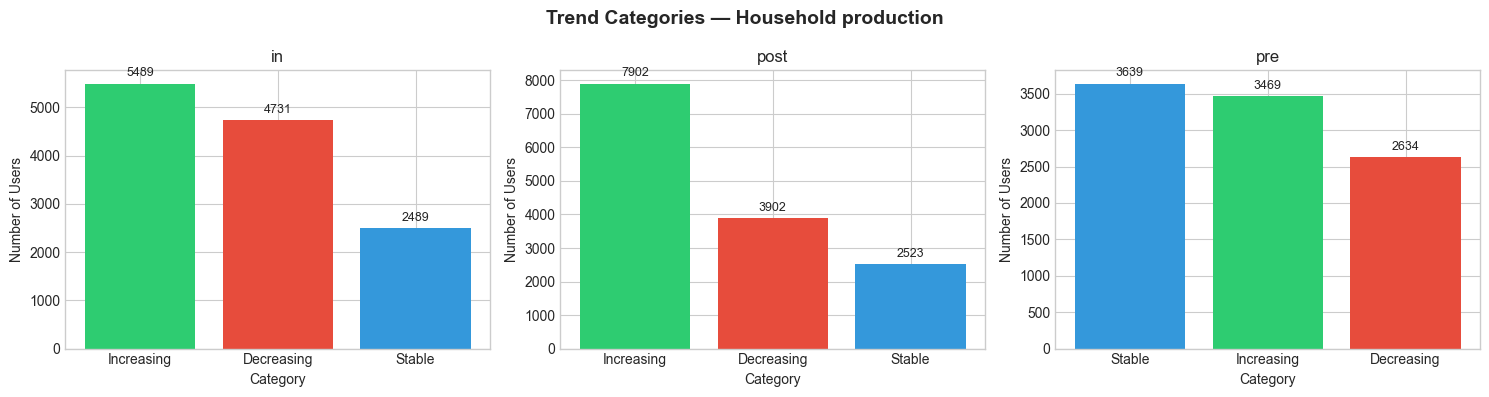

  ✔ Figure saved → results\figures\2c_household_production_trend_volatility_distributions.png


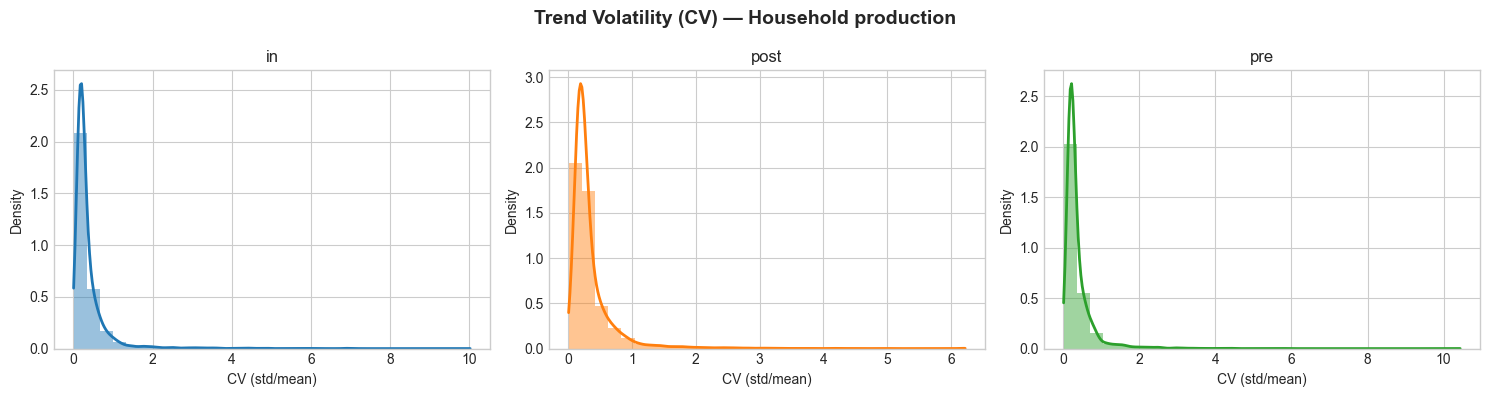

  ✔ Figure saved → results\figures\2d_household_production_trend_slope_vs_volatility.png


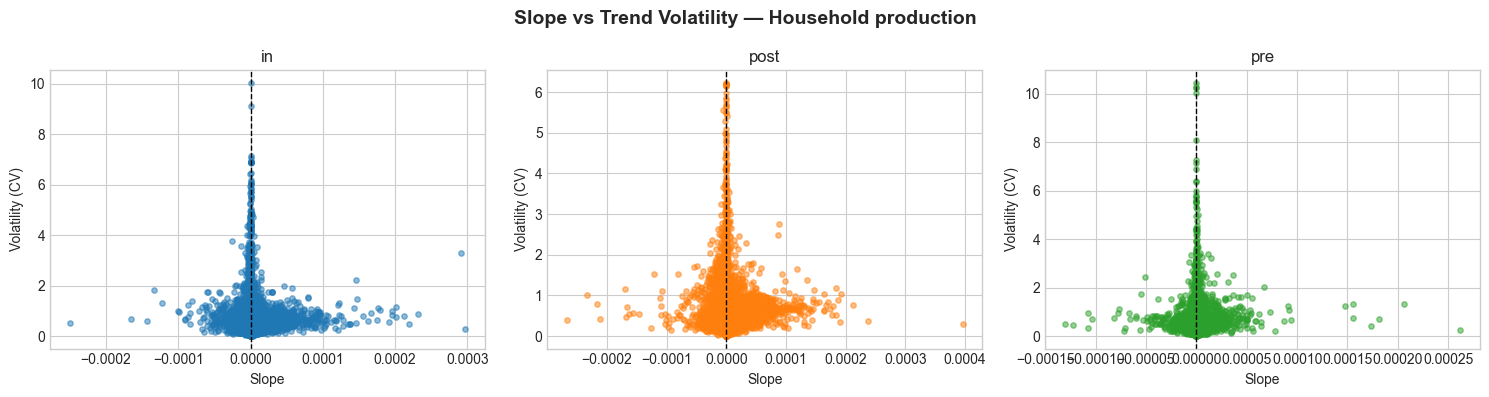

C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap


  ┌──────────────────────────────────────────────────────────────────────┐
  │  Trend — Trend Slope — Household production                          │
  └──────────────────────────────────────────────────────────────────────┘
          N      Mean    Median       Std       Min       P25       P75       Max  Skewness
in    12709  0.000003  0.000000  0.000016 -0.000250 -0.000003  0.000004  0.000297  3.729096
post  14327  0.000004  0.000002  0.000018 -0.000267 -0.000001  0.000006  0.000396  2.377629
pre    9742  0.000001  0.000000  0.000009 -0.000131 -0.000001  0.000002  0.000262  5.797881

  ✔ Table saved → results\tables\T3_household_production_trend_trend_slope.csv

  ┌──────────────────────────────────────────────────────────────────────┐
  │  Trend — Trend Mean — Household production                           │
  └──────────────────────────────────────────────────────────────────────┘
          N      Mean    Median       Std  Min       P25       P75       Max  Skewness
in    12709  

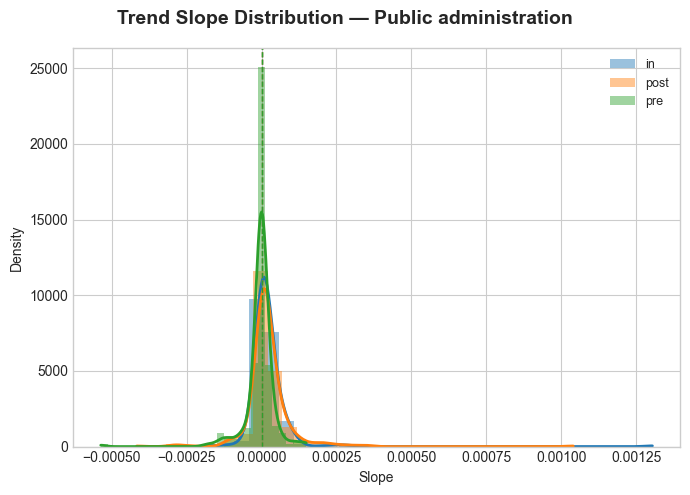

  ✔ Figure saved → results\figures\2b_public_administration_trend_categories_bar.png


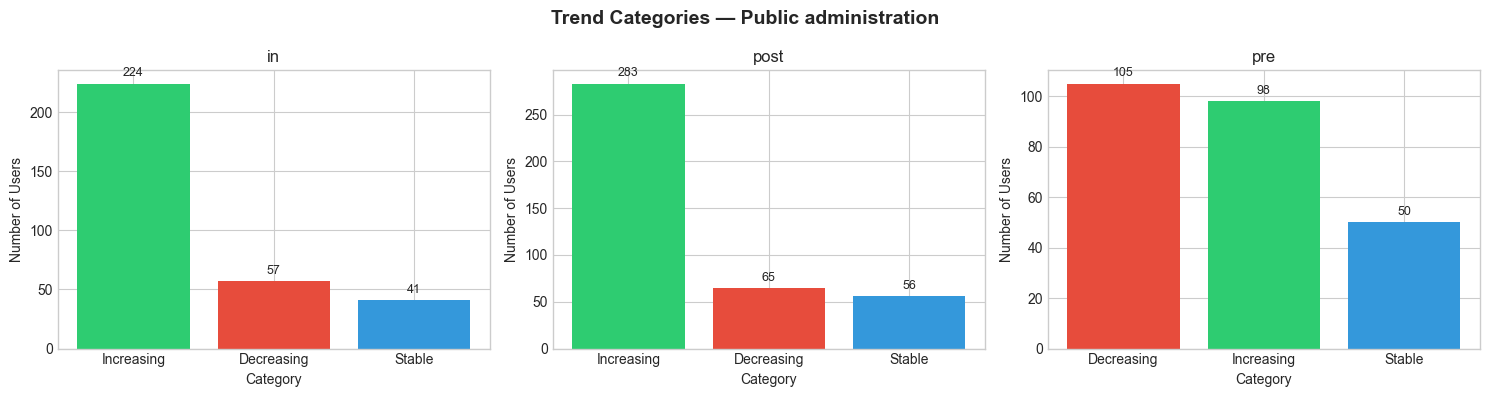

  ✔ Figure saved → results\figures\2c_public_administration_trend_volatility_distributions.png


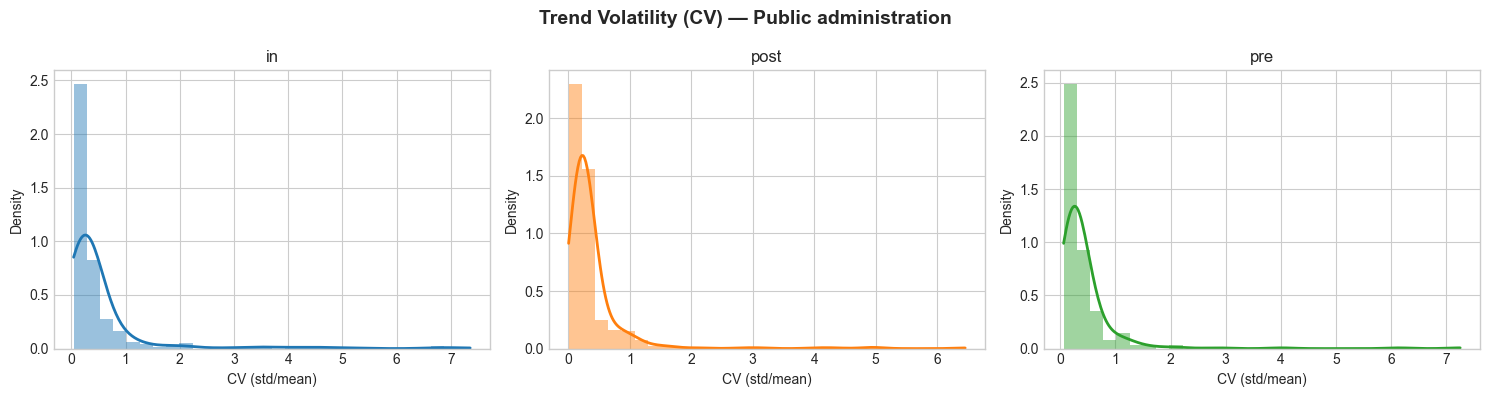

  ✔ Figure saved → results\figures\2d_public_administration_trend_slope_vs_volatility.png


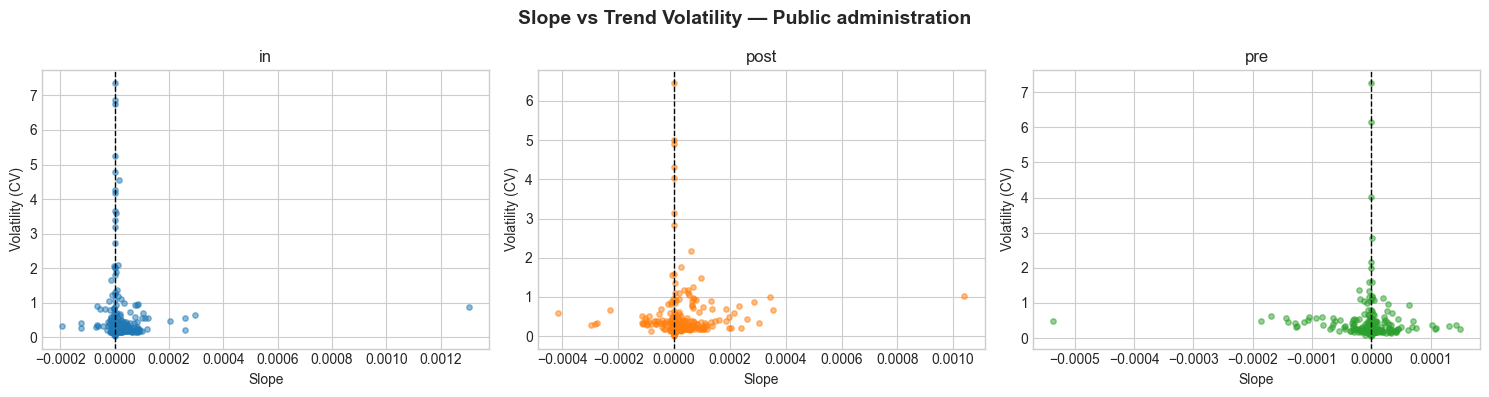


  ┌──────────────────────────────────────────────────────────────────────┐
  │  Trend — Trend Slope — Public administration                         │
  └──────────────────────────────────────────────────────────────────────┘
        N      Mean    Median       Std       Min       P25       P75       Max   Skewness
in    322  0.000022  0.000007  0.000083 -0.000191  0.000000  0.000027  0.001304  11.560663
post  404  0.000021  0.000008  0.000085 -0.000416  0.000000  0.000031  0.001040   4.287857
pre   253 -0.000005 -0.000000  0.000053 -0.000536 -0.000007  0.000007  0.000149  -4.395266

  ✔ Table saved → results\tables\T3_public_administration_trend_trend_slope.csv

  ┌──────────────────────────────────────────────────────────────────────┐
  │  Trend — Trend Mean — Public administration                          │
  └──────────────────────────────────────────────────────────────────────┘
        N      Mean    Median       Std  Min       P25       P75        Max  Skewness
in    322  0.9287

C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap

  ✔ [1] Sector 'Household production': 16311 users
  ✔ [2] Sector 'Public administration': 612 users
  ✔ [3] Sector 'Warehousing and logistics': 481 users
  ✔ [4] Sector 'Retail trade': 346 users
  ✔ [5] Sector 'Education': 211 users
  ✔ [6] Sector 'Food and beverage services': 210 users
  ✔ [7] Sector 'Associations': 171 users
  ✔ [8] Sector 'Sports and recreation': 126 users
  ✔ [9] Sector 'Construction (buildings)': 89 users
  ✔ [10] Sector 'Personal services': 82 users
  ✔ [11] Sector 'Other professional services': 80 users
  ✔ [12] Sector 'Wholesale trade': 72 users
  ✔ [13] Sector 'Agriculture, livestock, fishing': 71 users
  ✔ [14] Sector 'Water supply': 53 users
  ✔ [15] Sector 'Accommodation': 45 users
  ✔ [16] Sector 'Real estate': 45 users
  ✔ [17] Sector 'Healthcare': 44 users
  ✔ [18] Sector 'Specialized construction': 37 users
  ✔ [19] Sector 'Vehicle trade and repair': 36 users
  ✔ [20] Sector 'Social work': 33 users
  ✔ [21] Sector 'Travel agencies': 31 users
  ✔ [22] S

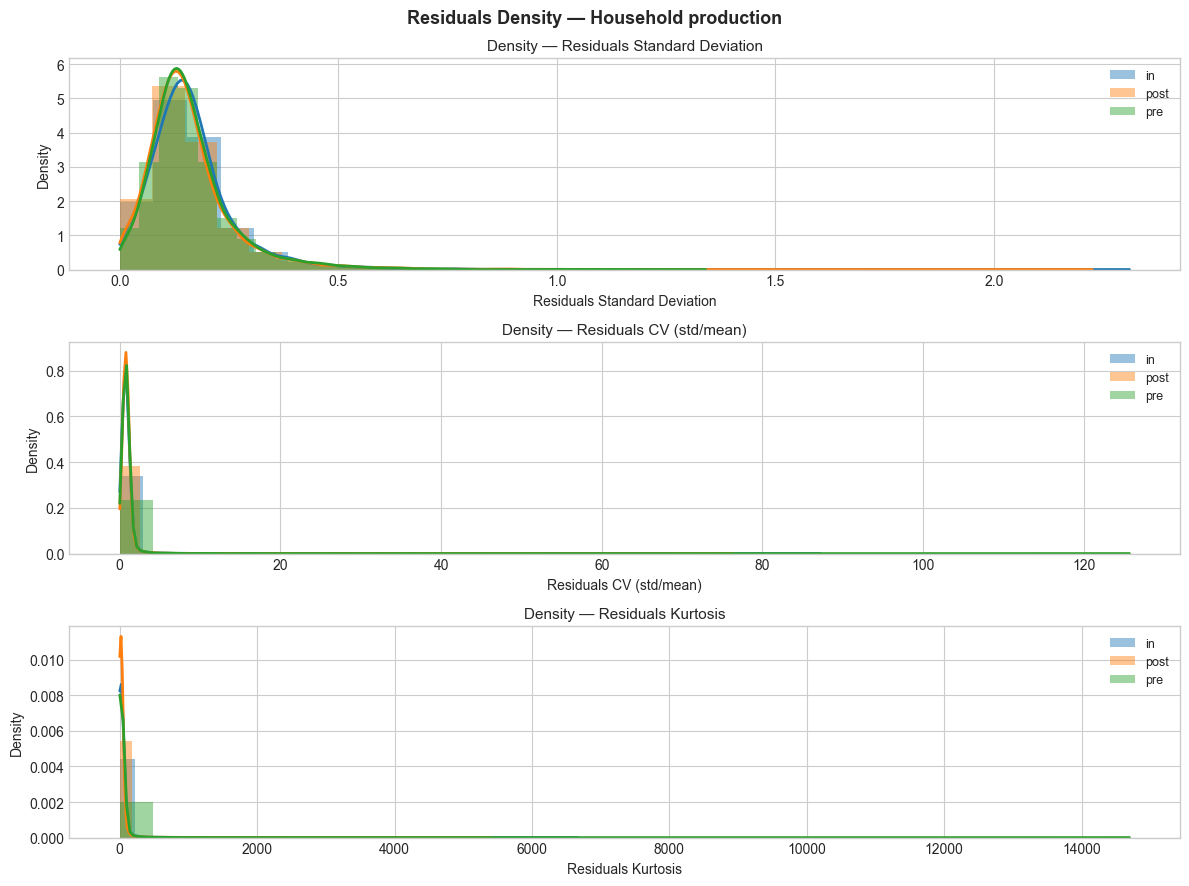

  ✔ Figure saved → results\figures\3a_household_production_residual_density_extreme.png


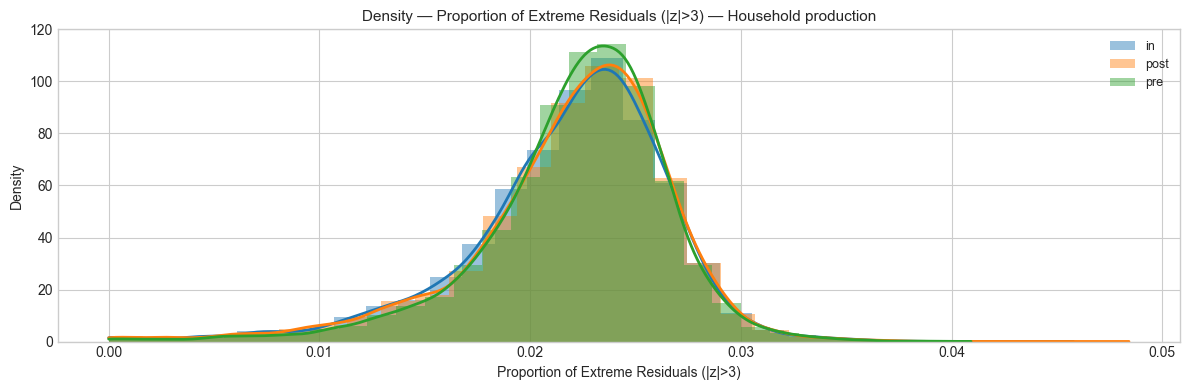

  ✔ Figure saved → results\figures\3b_household_production_residual_boxplot_residual_std.png


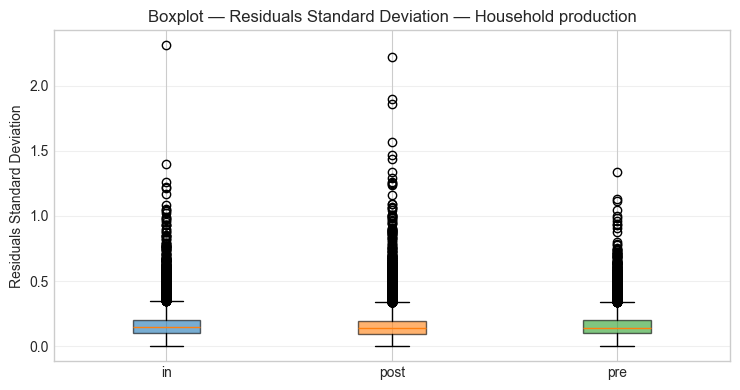

  ✔ Figure saved → results\figures\3b_household_production_residual_boxplot_residual_cv.png


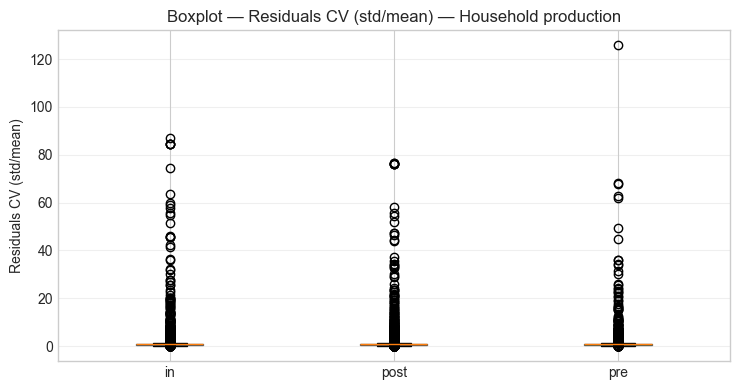

  ✔ Figure saved → results\figures\3c_household_production_residual_correlation_in.png


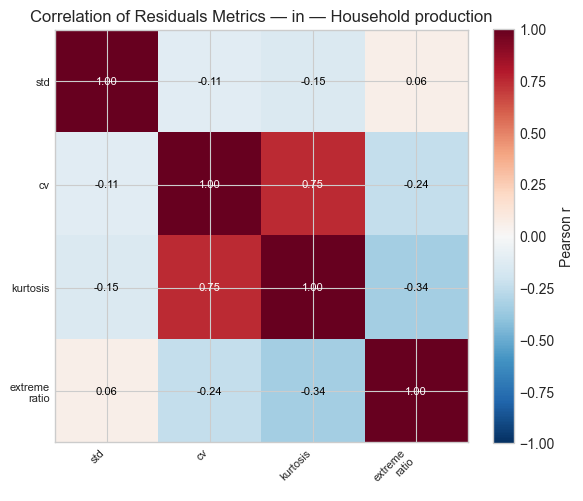

  ✔ Figure saved → results\figures\3c_household_production_residual_correlation_post.png


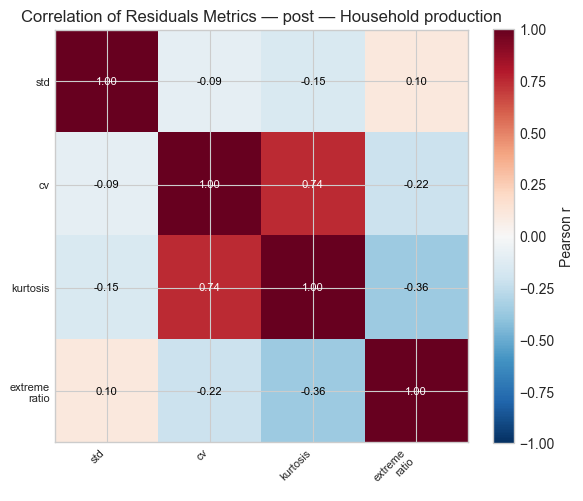

  ✔ Figure saved → results\figures\3c_household_production_residual_correlation_pre.png


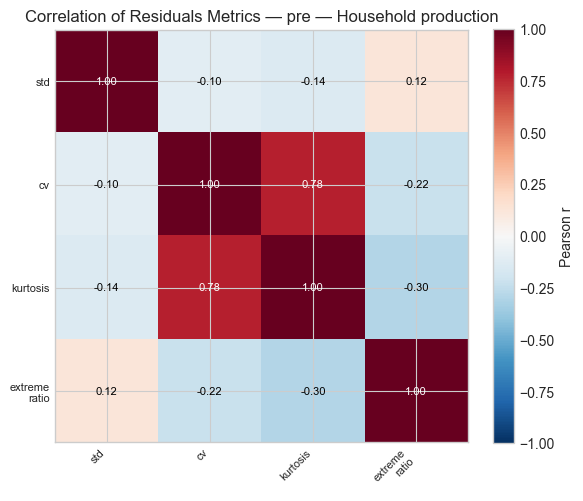


  ┌──────────────────────────────────────────────────────────────────────┐
  │  Residuals — Variance — Household production                         │
  └──────────────────────────────────────────────────────────────────────┘
          N      Mean    Median       Std  Min       P25       P75       Max   Skewness
in    12709  0.039034  0.022020  0.085654  0.0  0.010367  0.040263  5.337523  24.022370
post  14327  0.038588  0.019460  0.101400  0.0  0.009285  0.036995  4.949453  19.841010
pre    9742  0.036786  0.020405  0.063647  0.0  0.010233  0.038802  1.796810   8.431373

  ✔ Table saved → results\tables\T6_household_production_residuals_residual_variance.csv

  ┌──────────────────────────────────────────────────────────────────────┐
  │  Residuals — Standard Deviation — Household production               │
  └──────────────────────────────────────────────────────────────────────┘
          N      Mean    Median       Std  Min       P25       P75       Max  Skewness
in    12709  0.1651

C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap

  ✔ Figure saved → results\figures\3a_public_administration_residual_density_main.png


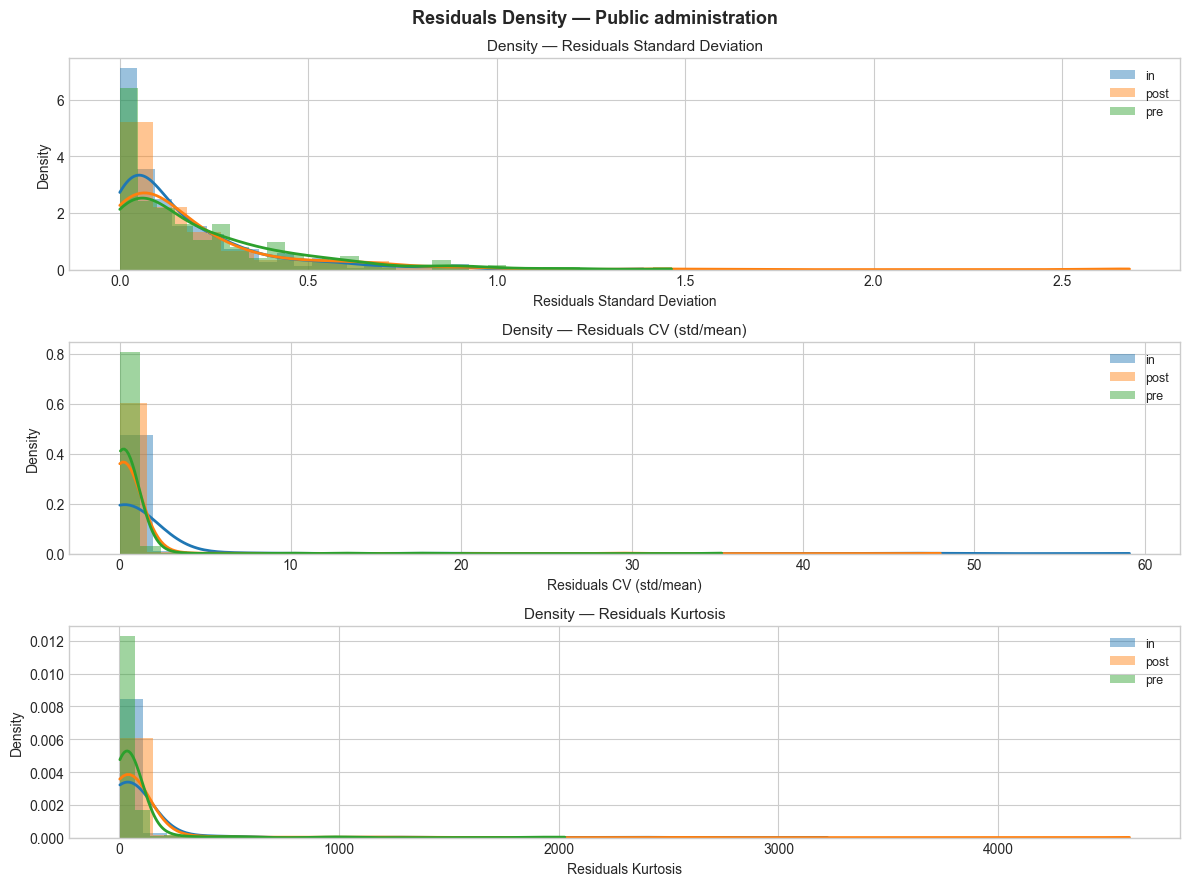

  ✔ Figure saved → results\figures\3a_public_administration_residual_density_extreme.png


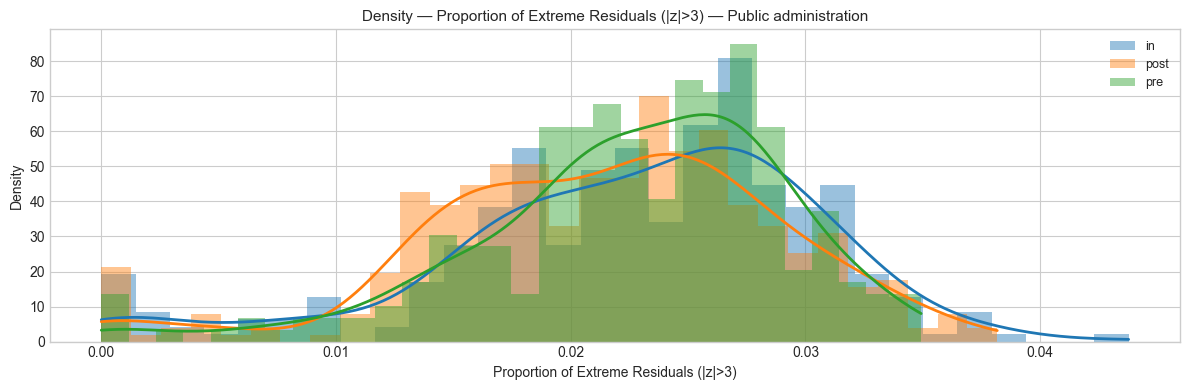

  ✔ Figure saved → results\figures\3b_public_administration_residual_boxplot_residual_std.png


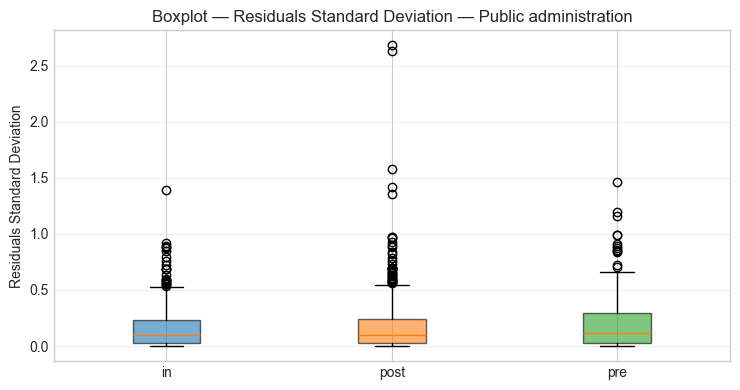

  ✔ Figure saved → results\figures\3b_public_administration_residual_boxplot_residual_cv.png


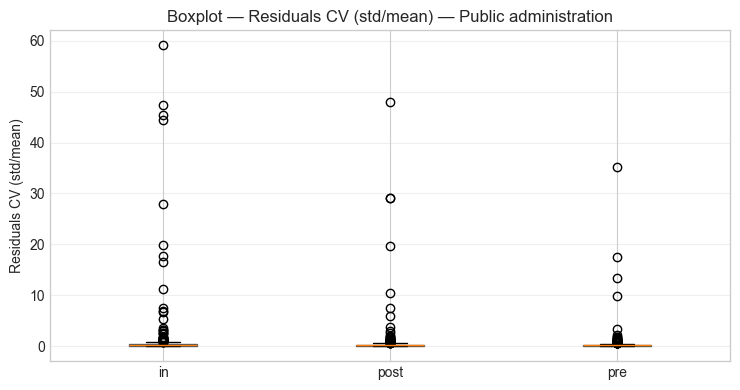

  ✔ Figure saved → results\figures\3c_public_administration_residual_correlation_in.png


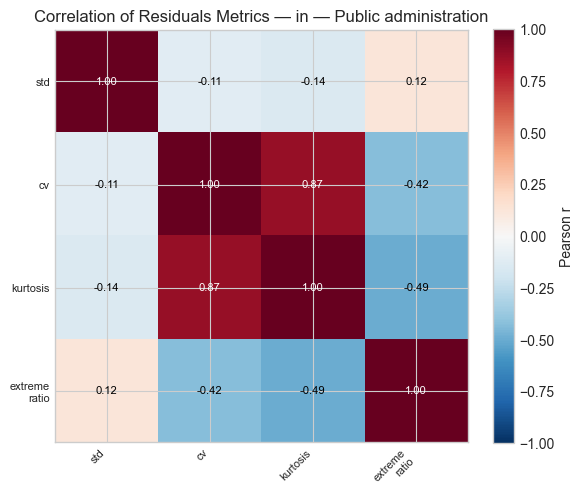

  ✔ Figure saved → results\figures\3c_public_administration_residual_correlation_post.png


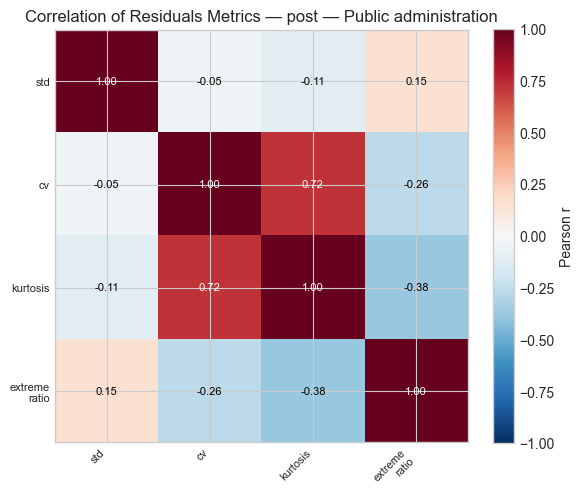

  ✔ Figure saved → results\figures\3c_public_administration_residual_correlation_pre.png


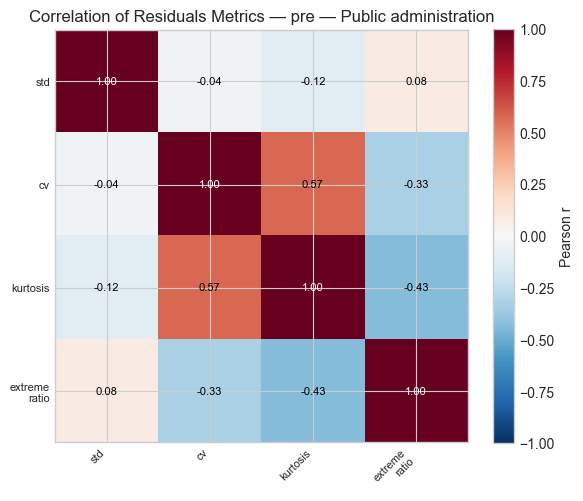


  ┌──────────────────────────────────────────────────────────────────────┐
  │  Residuals — Variance — Public administration                        │
  └──────────────────────────────────────────────────────────────────────┘
        N      Mean    Median       Std  Min       P25       P75       Max   Skewness
in    322  0.066964  0.009324  0.168932  0.0  0.000836  0.052387  1.929621   5.856734
post  404  0.121399  0.010256  0.542363  0.0  0.000857  0.058719  7.176428  10.791397
pre   253  0.104443  0.013596  0.239873  0.0  0.000824  0.086810  2.143073   4.604349

  ✔ Table saved → results\tables\T6_public_administration_residuals_residual_variance.csv

  ┌──────────────────────────────────────────────────────────────────────┐
  │  Residuals — Standard Deviation — Public administration              │
  └──────────────────────────────────────────────────────────────────────┘
        N      Mean    Median       Std  Min       P25       P75       Max  Skewness
in    322  0.165989  0.09656

C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap

  ✔ [1] Sector 'Household production': 16311 users
  ✔ [2] Sector 'Public administration': 612 users
  ✔ [3] Sector 'Warehousing and logistics': 481 users
  ✔ [4] Sector 'Retail trade': 346 users
  ✔ [5] Sector 'Education': 211 users
  ✔ [6] Sector 'Food and beverage services': 210 users
  ✔ [7] Sector 'Associations': 171 users
  ✔ [8] Sector 'Sports and recreation': 126 users
  ✔ [9] Sector 'Construction (buildings)': 89 users
  ✔ [10] Sector 'Personal services': 82 users
  ✔ [11] Sector 'Other professional services': 80 users
  ✔ [12] Sector 'Wholesale trade': 72 users
  ✔ [13] Sector 'Agriculture, livestock, fishing': 71 users
  ✔ [14] Sector 'Water supply': 53 users
  ✔ [15] Sector 'Accommodation': 45 users
  ✔ [16] Sector 'Real estate': 45 users
  ✔ [17] Sector 'Healthcare': 44 users
  ✔ [18] Sector 'Specialized construction': 37 users
  ✔ [19] Sector 'Vehicle trade and repair': 36 users
  ✔ [20] Sector 'Social work': 33 users
  ✔ [21] Sector 'Travel agencies': 31 users
  ✔ [22] S

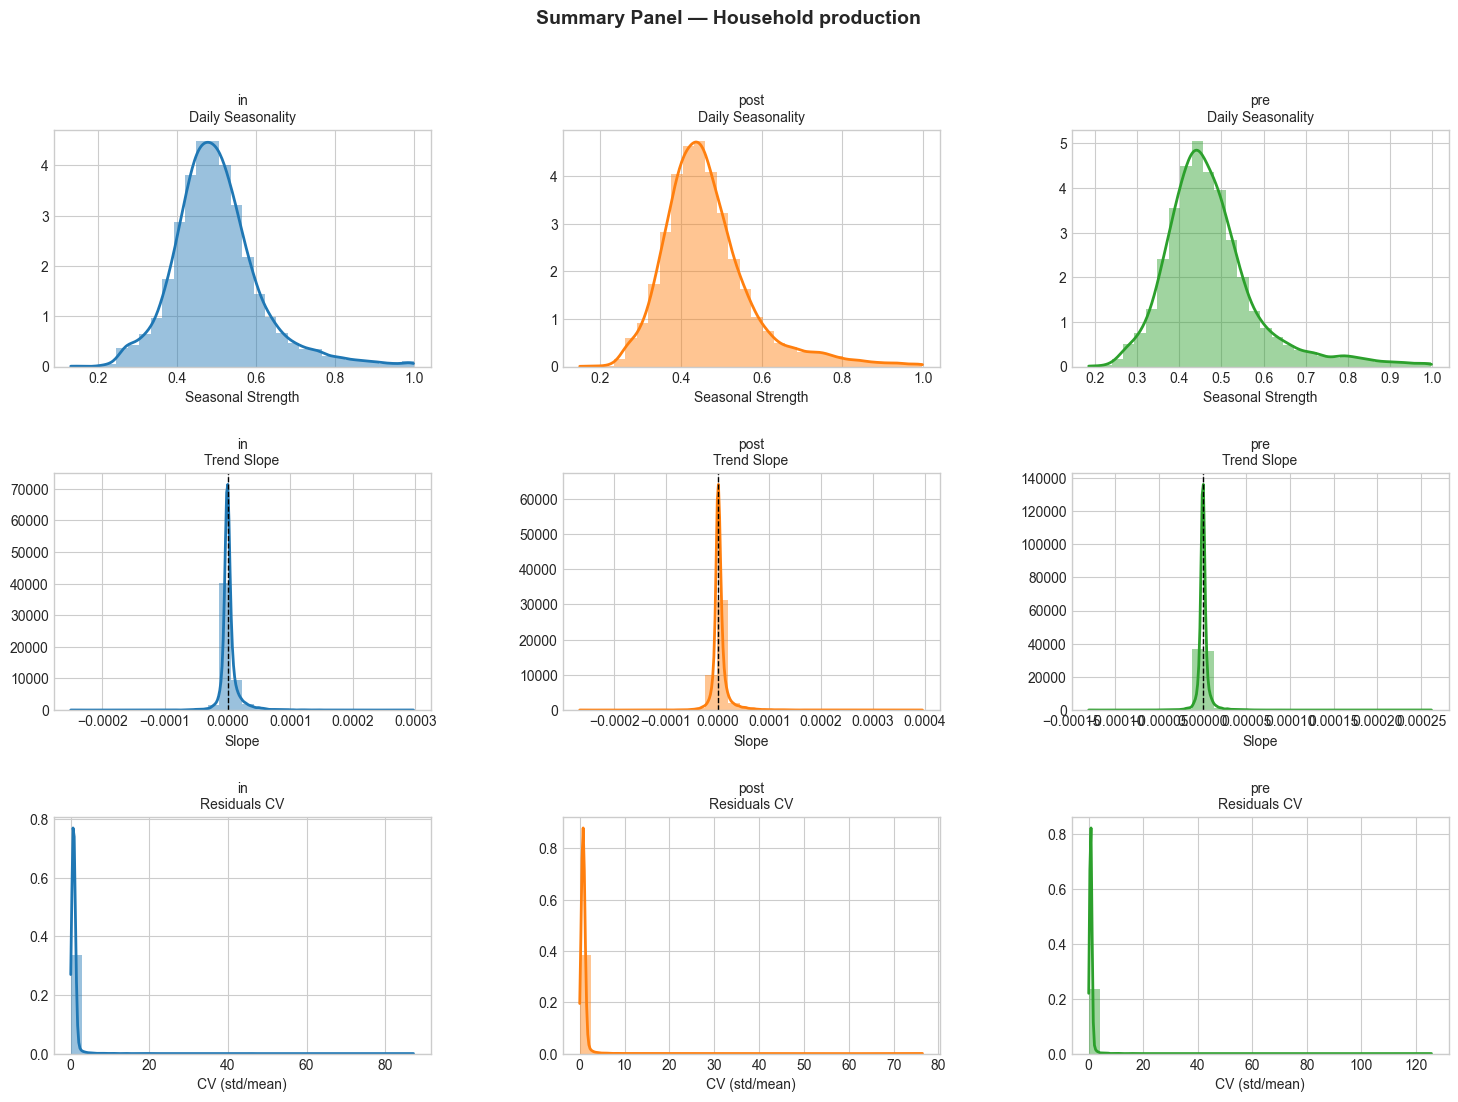


  ┌──────────────────────────────────────────────────────────────────────┐
  │  Master Table — Medians by Group — Household production              │
  └──────────────────────────────────────────────────────────────────────┘
       Daily Seasonality (md)  Weekly Seasonality (md)  Slope (md)  Volatility (md)  % Increasing  % Stable  % Decreasing  Residuals CV (md)  Extreme ratio (md)  Kurtosis (md)
Group                                                                                                                                                                          
in                     0.4895                   0.4972    0.000000           0.2311          43.2      19.6          37.2             0.7133              0.0226        14.5422
post                   0.4483                   0.4639    0.000002           0.2341          55.2      17.6          27.2             0.7613              0.0227        15.5458
pre                    0.4572                   0.4743    0.000000    

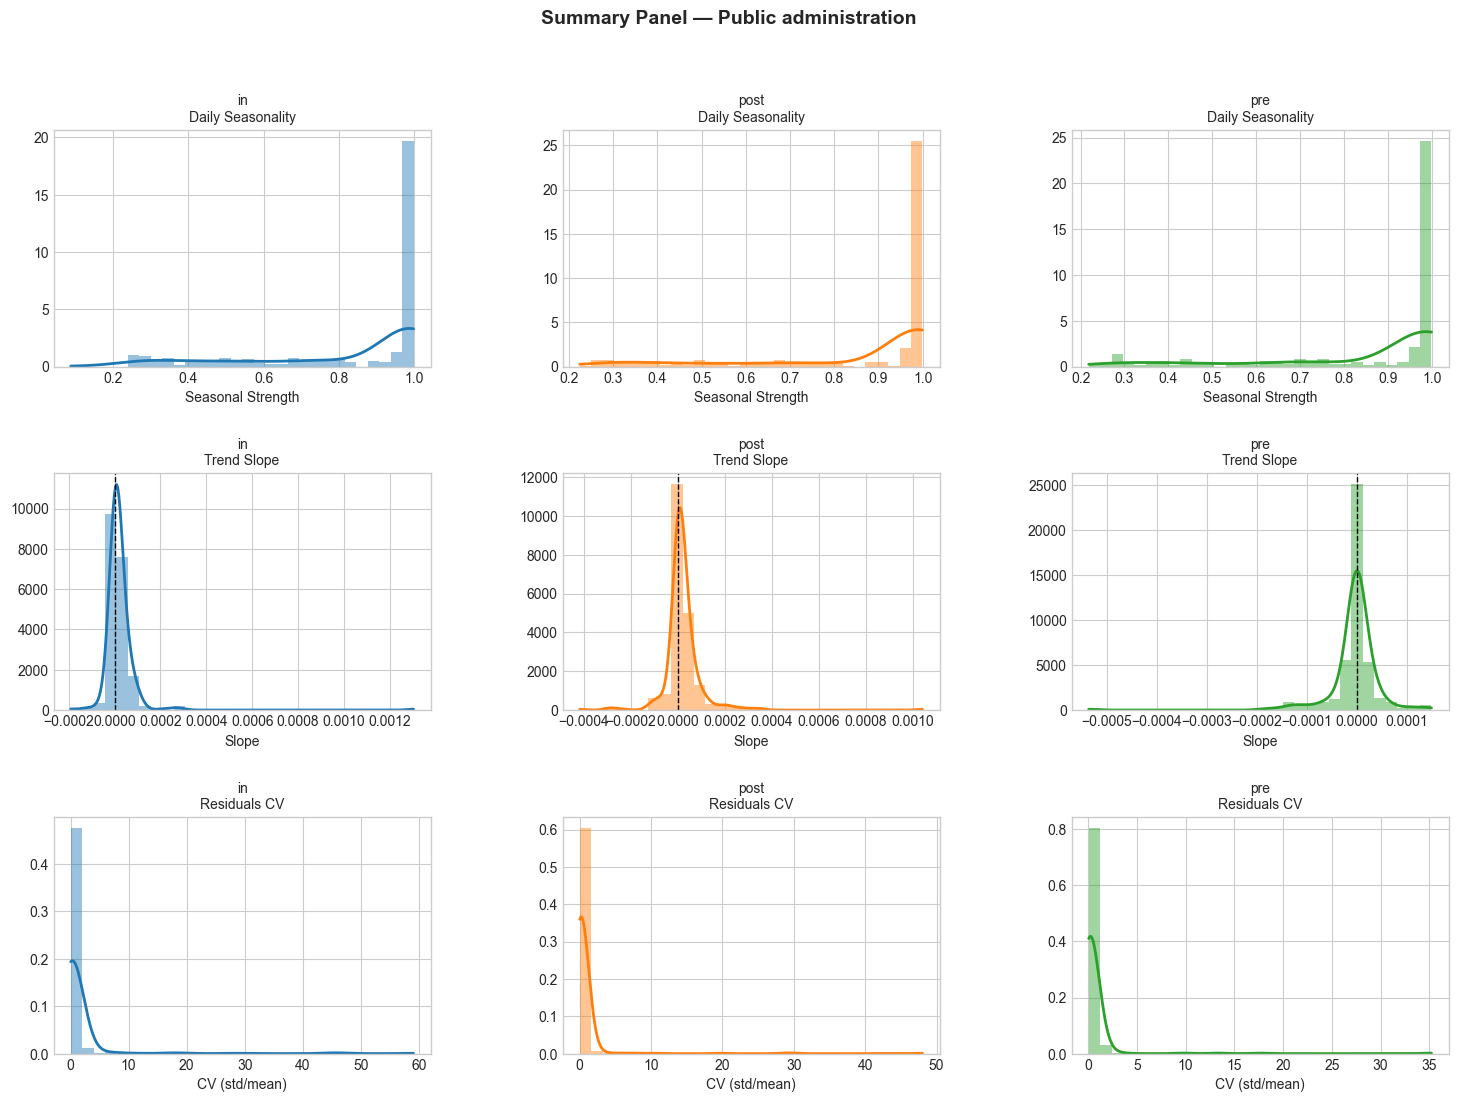


  ┌──────────────────────────────────────────────────────────────────────┐
  │  Master Table — Medians by Group — Public administration             │
  └──────────────────────────────────────────────────────────────────────┘
       Daily Seasonality (md)  Weekly Seasonality (md)  Slope (md)  Volatility (md)  % Increasing  % Stable  % Decreasing  Residuals CV (md)  Extreme ratio (md)  Kurtosis (md)
Group                                                                                                                                                                          
in                     0.9878                   0.9721    0.000007           0.2282          69.6      12.7          17.7             0.1558              0.0235        33.2946
post                   0.9901                   0.9782    0.000008           0.2202          70.0      13.9          16.1             0.1402              0.0221        37.6157
pre                    0.9854                   0.9729   -0.000000    

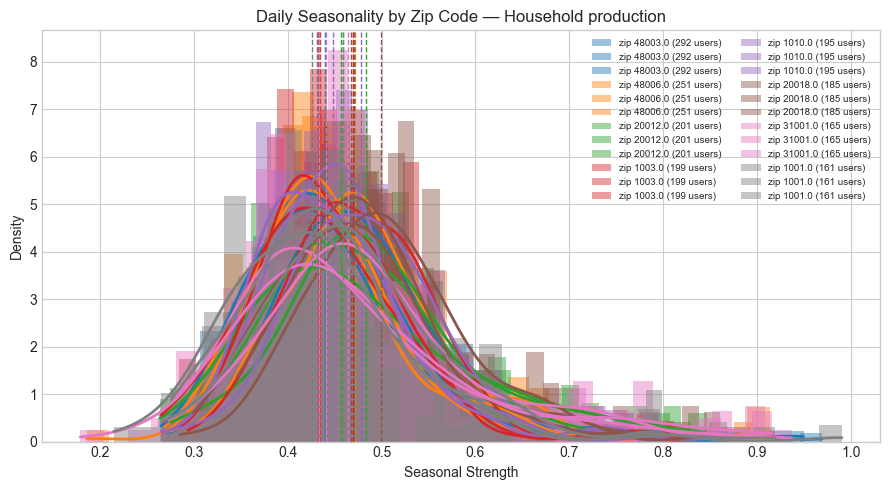

  ✔ Figure saved → results\figures\Z1_household_production_weekly_by_zip.png


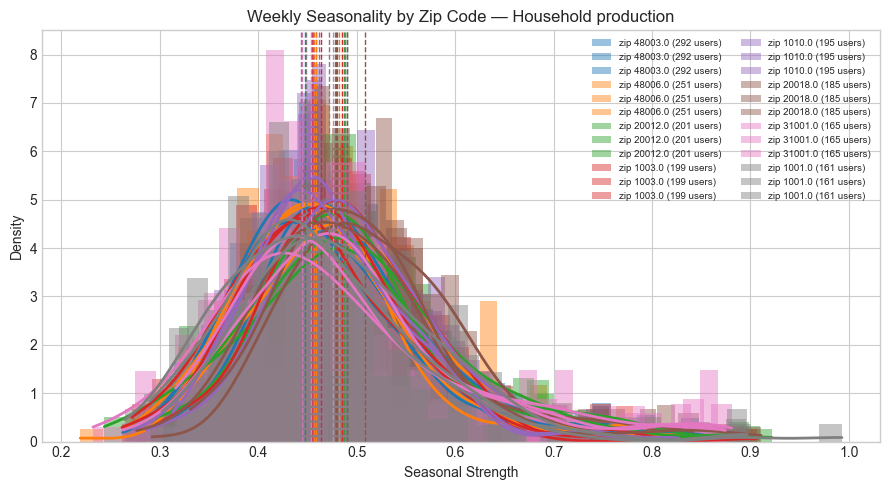

  ✔ Figure saved → results\figures\Z2_household_production_daily_boxplot_by_zip.png


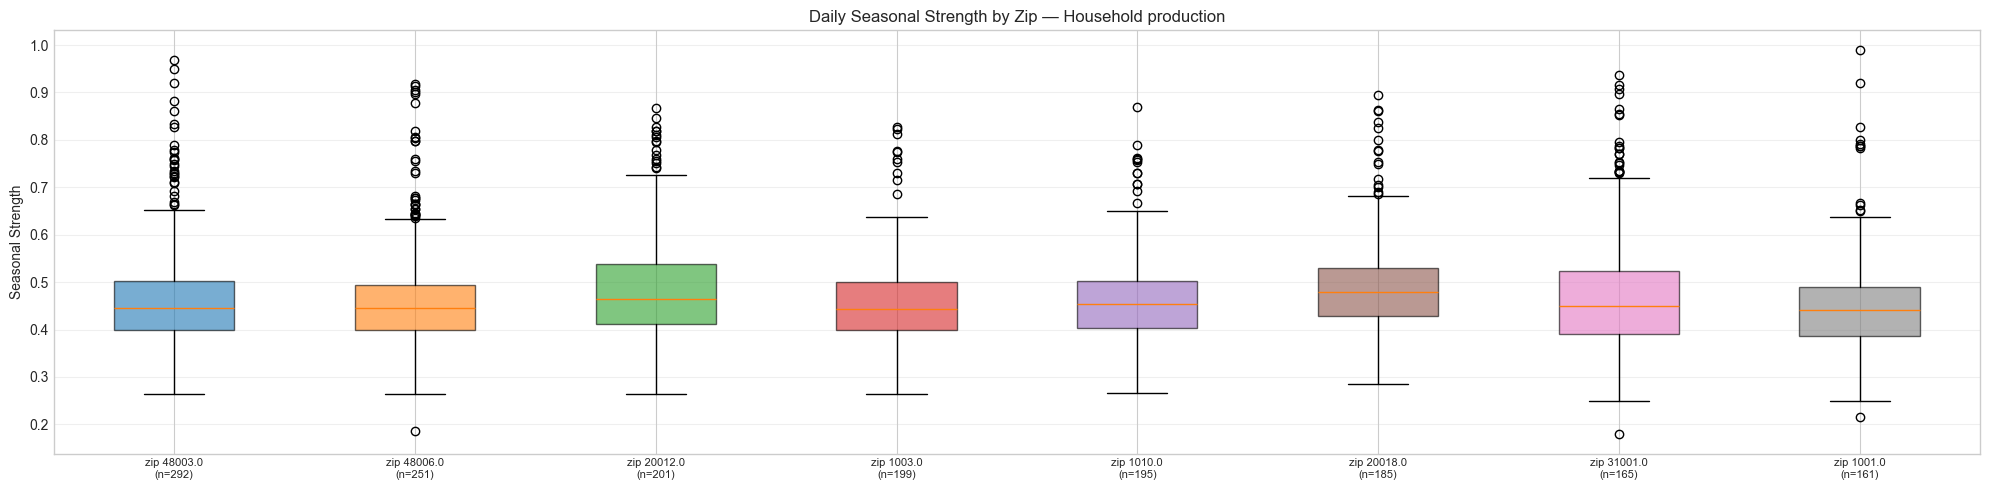

  ✔ Figure saved → results\figures\Z2_household_production_weekly_boxplot_by_zip.png


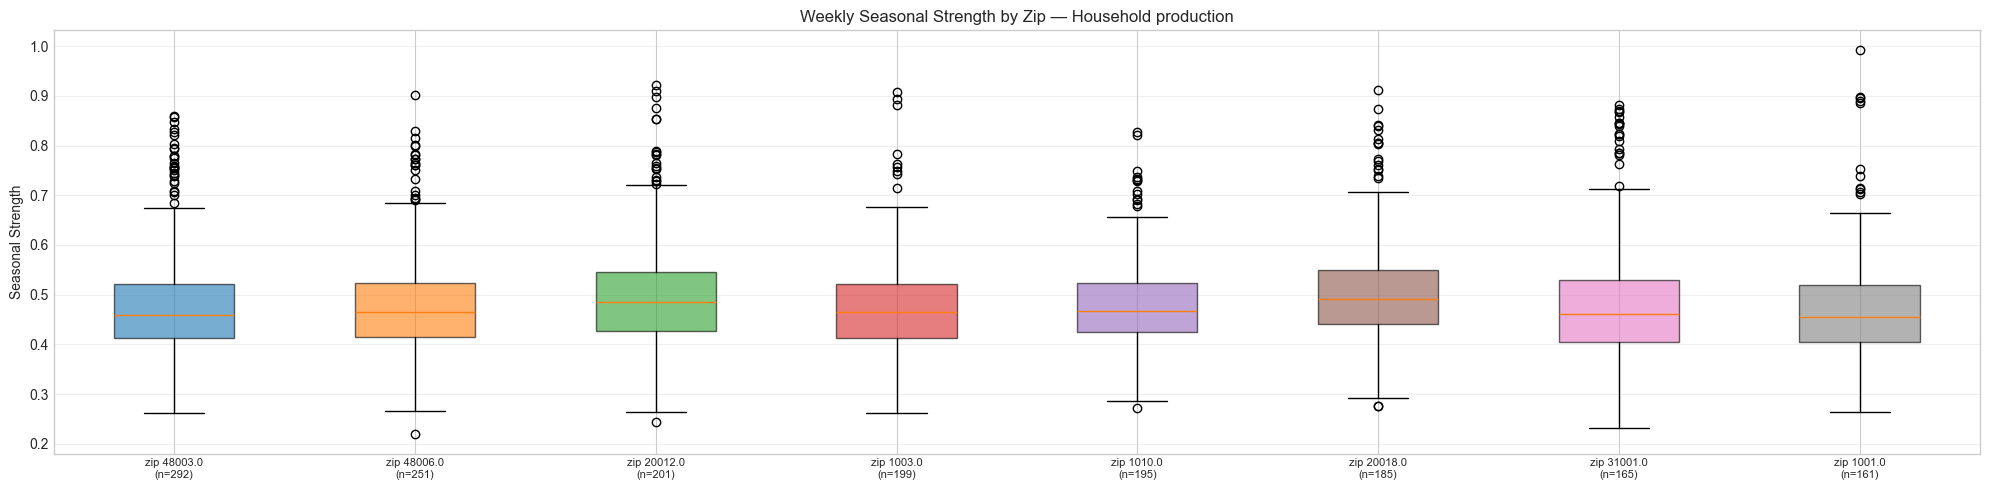


  ┌──────────────────────────────────────────────────────────────────────┐
  │  Seasonality Daily by Zip — Household production                     │
  └──────────────────────────────────────────────────────────────────────┘
               N      Mean    Median       Std       Min       P25       P75       Max  Skewness
zip 48003.0  676  0.462293  0.445000  0.097294  0.264946  0.399082  0.503384  0.969064  1.512182
zip 48006.0  602  0.460208  0.446159  0.096473  0.185731  0.398756  0.493264  0.918063  1.589284
zip 20012.0  447  0.484922  0.465263  0.110464  0.264189  0.411912  0.537854  0.868188  0.853053
zip 1003.0   467  0.455062  0.442790  0.084085  0.264980  0.398306  0.501004  0.827291  1.036782
zip 1010.0   481  0.461788  0.454230  0.083988  0.265325  0.403069  0.502333  0.869467  1.026650
zip 20018.0  399  0.490148  0.479368  0.094820  0.285611  0.428089  0.530177  0.893757  1.146959
zip 31001.0  359  0.474624  0.449855  0.123504  0.178996  0.391493  0.523170  0.936934  1.18956

C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
C:\Users\GONCA\AppData\Local\Temp\ipykernel_8980\1795657823.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\GONCA\\Desktop\\Iscte\\MCD\\Theses\\Dataset\\merged_imp_csv'

In [7]:
# adjust according to your project
SAVE_FIGS  = True                    # True → saves PNGs; False → only shows
SAVE_TABLES = True                   # True → saves CSVs + Excel tables
FIG_DIR    = OUTPUT_DIR / "figures"
TABLE_DIR  = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Global collection of tables for the final Excel report
_excel_sheets: dict[str, pd.DataFrame] = {}

# ── Helpers ────────────────────────────────────────────────────────────────

def _save_or_show(fig, name: str):
    if SAVE_FIGS:
        path = FIG_DIR / f"{name}.png"
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"  ✔ Figure saved → {path}")
    plt.show()
    plt.close(fig)

def _save_table(df: pd.DataFrame, name: str, title: str = ""):
    """Prints the table to the terminal, saves CSV, and registers for Excel."""
    sep = "─" * 70
    if title:
        print(f"\n  ┌{sep}┐")
        print(f"  │  {title:<68}│")
        print(f"  └{sep}┘")
    print(df.to_string(index=True))
    print()

    if SAVE_TABLES:
        csv_path = TABLE_DIR / f"{name}.csv"
        df.to_csv(csv_path)
        print(f"  ✔ Table saved → {csv_path}")

    # register for Excel
    sheet_name = name[:31]   # Excel limits to 31 characters
    _excel_sheets[sheet_name] = df

def _describe(series: pd.Series) -> dict:
    """Full descriptive statistics for a numeric series."""
    s = series.replace([np.inf, -np.inf], np.nan).dropna()
    return {
        "N":       len(s),
        "Mean":    s.mean(),
        "Median":  s.median(),
        "Std":     s.std(),
        "Min":     s.min(),
        "P25":     s.quantile(0.25),
        "P75":     s.quantile(0.75),
        "Max":     s.max(),
        "Skewness": skew(s),
    }

def _summary_table(data_dict: dict[str, pd.Series], fmt: str = "{:.4f}") -> pd.DataFrame:
    """Creates a DataFrame of descriptive statistics from {label: Series}."""
    rows = {label: _describe(s) for label, s in data_dict.items()}
    df   = pd.DataFrame(rows).T
    numeric_cols = df.columns[df.columns != "N"]
    df[numeric_cols] = df[numeric_cols].applymap(lambda x: float(f"{x:.6f}"))
    df["N"] = df["N"].astype(int)
    return df

def kde_hist(ax, data, color, label=None, bins=30):
    """Histogram + KDE curve overlay."""
    data = data.dropna()
    ax.hist(data, bins=bins, density=True, alpha=0.45, color=color, label=label)
    if len(data) > 3:
        kde  = gaussian_kde(data)
        xs   = np.linspace(data.min(), data.max(), 300)
        ax.plot(xs, kde(xs), color=color, lw=2)

def load_all(pattern: str) -> dict[str, pd.DataFrame]:
    """Returns {suffix: DataFrame} for all files matching the pattern."""
    files = sorted(OUTPUT_DIR.glob(pattern))
    if not files:
        print(f"  ⚠  No files found for: {pattern}")
    return {f.stem.split("_")[-1]: pd.read_csv(f) for f in files}

# ── Sector helpers ─────────────────────────────────────────────────────────

def _get_all_sectors(id_col: str = "user") -> dict[str, set]:
    """Returns {sector_label: set_of_user_ids} for every sector in metadata."""
    meta_path = OUTPUT_DIR.parent / "filtered_metadata.csv"
    if not meta_path.exists():
        print(f"  ⚠  Metadata file not found at {meta_path}")
        return {}
    meta_df = pd.read_csv(meta_path)
    if "sector" not in meta_df.columns:
        print(f"  ⚠  No 'sector' column. Columns: {meta_df.columns.tolist()}")
        return {}
    sectors = {
        sector: set(grp[id_col])
        for sector, grp in meta_df.groupby("sector")
    }
    # Sort by descending user count so the largest sectors are processed first
    sectors = dict(sorted(sectors.items(), key=lambda x: len(x[1]), reverse=True))
    for rank, (s, ids) in enumerate(sectors.items(), start=1):
        print(f"  ✔ [{rank}] Sector '{s}': {len(ids)} users")
    # Only return the two largest sectors
    return dict(list(sectors.items())[:2])


def _filter_by_ids(d: dict, valid_ids: set, id_col: str = "user") -> dict:
    """Filters a {suffix: DataFrame} dict to rows whose id_col is in valid_ids."""
    out = {}
    for suffix, df in d.items():
        kept = df[df[id_col].isin(valid_ids)] if id_col in df.columns else df
        if not kept.empty:
            out[suffix] = kept
    return out

def _get_zip_groups(
    sector: str = "Household production",
    id_col: str = "user",
    zip_col: str = "zip_code",
    min_users: int = MIN_ZIP_USERS,
) -> dict[str, set]:
    """
    Returns {zip_code: set_of_user_ids} for users in `sector`,
    sorted by descending user count and filtered to zips with >= min_users.
    """
    meta_path = OUTPUT_DIR.parent / "filtered_metadata.csv"
    if not meta_path.exists():
        print(f"  ⚠  Metadata file not found at {meta_path}")
        return {}

    meta_df = pd.read_csv(meta_path)

    if "sector" not in meta_df.columns:
        print(f"  ⚠  No 'sector' column found.")
        return {}
    if zip_col not in meta_df.columns:
        print(f"  ⚠  No '{zip_col}' column found. Columns: {meta_df.columns.tolist()}")
        return {}

    subset = meta_df[meta_df["sector"] == sector].copy()
    print(f"  ✔ Sector '{sector}': {len(subset)} users total")

    groups = {
        str(z): set(grp[id_col])
        for z, grp in subset.groupby(zip_col)
    }
    # Sort descending by count, drop zips below threshold
    groups = {
        z: ids for z, ids in
        sorted(groups.items(), key=lambda x: len(x[1]), reverse=True)
        if len(ids) >= min_users
    }
    print(f"  ✔ {len(groups)} zip codes with >= {min_users} users:")
    for rank, (z, ids) in enumerate(groups.items(), start=1):
        print(f"      [{rank}] zip {z}: {len(ids)} users")
    return groups


# ── 1. Seasonality ──────────────────────────────────────────────────────────

def plot_seasonality():
    daily_dict_all  = load_all("seasonality_results_daily_*.csv")
    weekly_dict_all = load_all("seasonality_results_weekly_*.csv")

    sectors = _get_all_sectors()

    # Fallback: no metadata → treat everything as one unnamed sector
    if not sectors:
        sectors = {"all": None}

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for sector_name, valid_ids in sectors.items():
        print(f"\n  ── Sector: {sector_name} ──")

        if valid_ids is not None:
            daily_dict  = _filter_by_ids(daily_dict_all,  valid_ids)
            weekly_dict = _filter_by_ids(weekly_dict_all, valid_ids)
        else:
            daily_dict, weekly_dict = daily_dict_all, weekly_dict_all

        suffixes = sorted(set(daily_dict) | set(weekly_dict))
        if not suffixes:
            print("  ⚠  No data for this sector — skipping.")
            continue

        slug = sector_name.lower().replace(" ", "_")   # safe filename part

        # ── Daily — All Groups ────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(6, 4))
        for col_i, suffix in enumerate(suffixes):
            color = colors[col_i % len(colors)]
            if suffix in daily_dict:
                kde_hist(ax, daily_dict[suffix]["seasonal_strength_daily"],
                         color=color, label=suffix)
                ax.axvline(daily_dict[suffix]["seasonal_strength_daily"].median(),
                           color=color, ls="--", lw=1.2)
        ax.set_title(f"Daily Seasonality — {sector_name}")
        ax.set_xlabel("Seasonal Strength")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        plt.tight_layout()
        _save_or_show(fig, f"1a_{slug}_daily")

        # ── Weekly — All Groups ───────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(6, 4))
        for col_i, suffix in enumerate(suffixes):
            color = colors[col_i % len(colors)]
            if suffix in weekly_dict:
                kde_hist(ax, weekly_dict[suffix]["seasonal_strength_weekly"],
                         color=color, label=suffix)
                ax.axvline(weekly_dict[suffix]["seasonal_strength_weekly"].median(),
                           color=color, ls="--", lw=1.2)
        ax.set_title(f"Weekly Seasonality — {sector_name}")
        ax.set_xlabel("Seasonal Strength")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        plt.tight_layout()
        _save_or_show(fig, f"1a_{slug}_weekly")

        # ── Comparison — Daily vs Weekly ──────────────────────────────────
        fig, ax = plt.subplots(figsize=(6, 4))
        for col_i, suffix in enumerate(suffixes):
            color = colors[col_i % len(colors)]
            if suffix in daily_dict:
                kde_hist(ax, daily_dict[suffix]["seasonal_strength_daily"],
                         color=color, label=f"{suffix} Daily")
            if suffix in weekly_dict:
                kde_hist(ax, weekly_dict[suffix]["seasonal_strength_weekly"],
                         color=color, label=f"{suffix} Weekly", bins=30)
        ax.set_title(f"Comparison Daily vs Weekly — {sector_name}")
        ax.set_xlabel("Seasonal Strength")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        plt.tight_layout()
        _save_or_show(fig, f"1a_{slug}_compare")

        # ── Daily vs Weekly boxplot ───────────────────────────────────────
        records = []
        for suffix in suffixes:
            for freq, dct, col in [
                ("Daily",  daily_dict,  "seasonal_strength_daily"),
                ("Weekly", weekly_dict, "seasonal_strength_weekly"),
            ]:
                if suffix in dct:
                    for v in dct[suffix][col].dropna():
                        records.append({"suffix": suffix, "Freq": freq, "Strength": v})

        if records:
            df_box = pd.DataFrame(records)
            groups = df_box.groupby(["suffix", "Freq"])["Strength"].apply(list)
            labels = [f"{s}\n{f}" for s, f in groups.index]
            fig, ax = plt.subplots(figsize=(max(6, 3 * len(labels)), 5))
            bp = ax.boxplot(list(groups), patch_artist=True)
            for patch, color in zip(bp["boxes"], colors * 10):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
            ax.set_xticks(range(1, len(labels) + 1))
            ax.set_xticklabels(labels, fontsize=9)
            ax.set_ylabel("Seasonal Strength")
            ax.set_title(f"Seasonal Strength Boxplot — {sector_name}")
            ax.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            _save_or_show(fig, f"1b_{slug}_boxplot")

        # ── Table 1 — Descriptive statistics ─────────────────────────────
        for freq_label, dct, col in [
            ("Daily",  daily_dict,  "seasonal_strength_daily"),
            ("Weekly", weekly_dict, "seasonal_strength_weekly"),
        ]:
            data_dict = {s: dct[s][col] for s in suffixes if s in dct}
            if not data_dict:
                continue
            tbl = _summary_table(data_dict)
            _save_table(tbl,
                        name=f"T1_{slug}_seasonality_{freq_label.lower()}",
                        title=f"Seasonality {freq_label} — {sector_name}")

        # ── Table 2 — % users above thresholds ───────────────────────────
        threshold_rows = []
        for suffix in suffixes:
            for freq_label, dct, col in [
                ("Daily",  daily_dict,  "seasonal_strength_daily"),
                ("Weekly", weekly_dict, "seasonal_strength_weekly"),
            ]:
                if suffix not in dct:
                    continue
                s = dct[suffix][col].dropna()
                for thr in [0.3, 0.5, 0.6, 0.8]:
                    threshold_rows.append({
                        "Group":      suffix,
                        "Frequency":  freq_label,
                        "Threshold":  thr,
                        "N above":    int((s > thr).sum()),
                        "% above":    round((s > thr).mean() * 100, 1),
                        "N total":    len(s),
                    })
        if threshold_rows:
            _save_table(pd.DataFrame(threshold_rows),
                        name=f"T2_{slug}_thresholds",
                        title=f"Seasonality Thresholds — {sector_name}")

# ── 2. Trend ────────────────────────────────────────────────────────────────

def plot_trend():
    trend_dict = load_all("trend_analysis_results_*.csv")

    sectors = _get_all_sectors()
    if not sectors:
        sectors = {"all": None}

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for sector_name, valid_ids in sectors.items():
        print(f"\n  ── Sector: {sector_name} ──")

        if valid_ids is not None:
            td = _filter_by_ids(trend_dict, valid_ids)
        else:
            td = trend_dict

        if not td:
            print("  ⚠  No trend data for this sector — skipping.")
            continue

        suffixes = sorted(td)
        n_suf    = len(suffixes)
        slug     = sector_name.lower().replace(" ", "_")

        # ── 2a. Slope distribution ────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(7, 5))
        fig.suptitle(f"Trend Slope Distribution — {sector_name}", fontsize=14, fontweight="bold")
        for i, suffix in enumerate(suffixes):
            color = colors[i % len(colors)]
            kde_hist(ax, td[suffix]["trend_slope"], color=color, label=suffix)
            ax.axvline(0, color=color, ls="--", lw=1)
        ax.set_xlabel("Slope")
        ax.set_ylabel("Density")
        ax.legend(fontsize=9)
        plt.tight_layout()
        _save_or_show(fig, f"2a_{slug}_trend_slope_distributions_merged")

        # ── 2b. Proportion of categories ─────────────────────────────────
        cat_col   = "trend_category"
        fig, axes = plt.subplots(1, n_suf, figsize=(5 * n_suf, 4), squeeze=False)
        fig.suptitle(f"Trend Categories — {sector_name}", fontsize=14, fontweight="bold")
        cat_colors = {"Increasing": "#2ecc71", "Stable": "#3498db", "Decreasing": "#e74c3c"}

        for i, suffix in enumerate(suffixes):
            ax   = axes[0][i]
            df   = td[suffix]
            cnts = df[cat_col].value_counts()
            bars = ax.bar(cnts.index, cnts.values,
                          color=[cat_colors.get(c, "grey") for c in cnts.index])
            ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
            ax.set_title(suffix)
            ax.set_ylabel("Number of Users")
            ax.set_xlabel("Category")
        plt.tight_layout()
        _save_or_show(fig, f"2b_{slug}_trend_categories_bar")

        # ── 2c. Trend volatility ──────────────────────────────────────────
        fig, axes = plt.subplots(1, n_suf, figsize=(5 * n_suf, 4), squeeze=False)
        fig.suptitle(f"Trend Volatility (CV) — {sector_name}", fontsize=14, fontweight="bold")
        for i, suffix in enumerate(suffixes):
            ax    = axes[0][i]
            color = colors[i % len(colors)]
            kde_hist(ax, td[suffix]["trend_volatility"].replace([np.inf, -np.inf], np.nan),
                     color=color)
            ax.set_title(suffix)
            ax.set_xlabel("CV (std/mean)")
            ax.set_ylabel("Density")
        plt.tight_layout()
        _save_or_show(fig, f"2c_{slug}_trend_volatility_distributions")

        # ── 2d. Scatter slope × volatility ───────────────────────────────
        fig, axes = plt.subplots(1, n_suf, figsize=(5 * n_suf, 4), squeeze=False)
        fig.suptitle(f"Slope vs Trend Volatility — {sector_name}", fontsize=14, fontweight="bold")
        for i, suffix in enumerate(suffixes):
            ax  = axes[0][i]
            df  = td[suffix].dropna(subset=["trend_slope", "trend_volatility"])
            ax.scatter(df["trend_slope"], df["trend_volatility"],
                       alpha=0.5, s=15, c=colors[i % len(colors)])
            ax.axvline(0, color="black", ls="--", lw=1)
            ax.set_title(suffix)
            ax.set_xlabel("Slope")
            ax.set_ylabel("Volatility (CV)")
        plt.tight_layout()
        _save_or_show(fig, f"2d_{slug}_trend_slope_vs_volatility")

        # ── Table 3 — Descriptive statistics of trend ─────────────────────
        for metric in ["trend_slope", "trend_mean", "trend_std", "trend_volatility"]:
            data_dict = {s: td[s][metric] for s in suffixes}
            tbl = _summary_table(data_dict)
            _save_table(tbl,
                        name=f"T3_{slug}_trend_{metric}",
                        title=f"Trend — {metric.replace('_', ' ').title()} — {sector_name}")

        # ── Table 4 — Count and % by trend category ───────────────────────
        cat_rows = []
        for suffix in suffixes:
            df    = td[suffix]
            cnts  = df["trend_category"].value_counts()
            total = len(df)
            for cat in ["Increasing", "Stable", "Decreasing"]:
                n = int(cnts.get(cat, 0))
                cat_rows.append({
                    "Group":    suffix,
                    "Category": cat,
                    "N":        n,
                    "%":        round(n / total * 100, 1) if total else 0,
                    "N total":  total,
                })
        _save_table(pd.DataFrame(cat_rows),
                    name=f"T4_{slug}_trend_categories",
                    title=f"Trend — Category Distribution — {sector_name}")

        # ── Table 5 — Slope comparison ────────────────────────────────────
        slope_data = {s: td[s]["trend_slope"] for s in suffixes}
        _save_table(_summary_table(slope_data),
                    name=f"T5_{slug}_trend_slope_comparison",
                    title=f"Trend — Slope Comparison — {sector_name}")

# ── 3. Residuals ───────────────────────────────────────────────────────────

def plot_residuals():
    resid_dict = load_all("residual_analysis_results_*.csv")

    sectors = _get_all_sectors()
    if not sectors:
        sectors = {"all": None}

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    metrics_main   = [
        ("residual_std",      "Residuals Standard Deviation"),
        ("residual_cv",       "Residuals CV (std/mean)"),
        ("residual_kurtosis", "Residuals Kurtosis"),
    ]
    metric_extreme = ("extreme_residual_ratio", "Proportion of Extreme Residuals (|z|>3)")

    for sector_name, valid_ids in sectors.items():
        print(f"\n  ── Sector: {sector_name} ──")

        if valid_ids is not None:
            rd = _filter_by_ids(resid_dict, valid_ids)
        else:
            rd = resid_dict

        if not rd:
            print("  ⚠  No residuals data for this sector — skipping.")
            continue

        suffixes = sorted(rd)
        n_suf    = len(suffixes)
        slug     = sector_name.lower().replace(" ", "_")

        # ── 3a. Distribution of main metrics ─────────────────────────────
        fig, axes = plt.subplots(len(metrics_main), 1, figsize=(12, 9))
        fig.suptitle(f"Residuals Density — {sector_name}", fontsize=13, fontweight="bold")
        for row_i, (metric, ylabel) in enumerate(metrics_main):
            for col_i, suffix in enumerate(suffixes):
                color = colors[col_i % len(colors)]
                kde_hist(axes[row_i],
                         rd[suffix][metric].replace([np.inf, -np.inf], np.nan),
                         color=color, label=suffix)
            axes[row_i].set_title(f"Density — {ylabel}", fontsize=11)
            axes[row_i].set_xlabel(ylabel)
            axes[row_i].set_ylabel("Density")
            axes[row_i].legend(fontsize=9)
        plt.tight_layout()
        _save_or_show(fig, f"3a_{slug}_residual_density_main")

        # ── 3a-extreme ────────────────────────────────────────────────────
        fig_ext, ax_ext = plt.subplots(figsize=(12, 4))
        metric, ylabel = metric_extreme
        for col_i, suffix in enumerate(suffixes):
            color = colors[col_i % len(colors)]
            kde_hist(ax_ext,
                     rd[suffix][metric].replace([np.inf, -np.inf], np.nan),
                     color=color, label=suffix)
        ax_ext.set_title(f"Density — {ylabel} — {sector_name}", fontsize=11)
        ax_ext.set_xlabel(ylabel)
        ax_ext.set_ylabel("Density")
        ax_ext.legend(fontsize=9)
        plt.tight_layout()
        _save_or_show(fig_ext, f"3a_{slug}_residual_density_extreme")

        # ── 3b. Boxplots ──────────────────────────────────────────────────
        for metric, ylabel in metrics_main[:2]:
            fig, ax = plt.subplots(figsize=(max(5, 2.5 * n_suf), 4))
            data_bp = [
                rd[s][metric].replace([np.inf, -np.inf], np.nan).dropna().values
                for s in suffixes
            ]
            bp = ax.boxplot(data_bp, patch_artist=True, notch=False)
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
            ax.set_xticks(range(1, n_suf + 1))
            ax.set_xticklabels(suffixes, fontsize=10)
            ax.set_ylabel(ylabel)
            ax.set_title(f"Boxplot — {ylabel} — {sector_name}")
            ax.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            _save_or_show(fig, f"3b_{slug}_residual_boxplot_{metric}")

        # ── 3c. Correlation heatmap ───────────────────────────────────────
        all_metrics = [m for m, _ in metrics_main] + [metric_extreme[0]]
        for suffix in suffixes:
            df   = rd[suffix]
            num  = df[all_metrics].replace([np.inf, -np.inf], np.nan)
            corr = num.corr()
            fig, ax = plt.subplots(figsize=(6, 5))
            im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
            plt.colorbar(im, ax=ax, label="Pearson r")
            ax.set_xticks(range(len(corr)))
            ax.set_yticks(range(len(corr)))
            labels_ax = [m.replace("residual_", "").replace("_", "\n") for m in corr.columns]
            ax.set_xticklabels(labels_ax, fontsize=8, rotation=45, ha="right")
            ax.set_yticklabels(labels_ax, fontsize=8)
            for ii in range(len(corr)):
                for jj in range(len(corr)):
                    ax.text(jj, ii, f"{corr.iloc[ii, jj]:.2f}",
                            ha="center", va="center", fontsize=8,
                            color="white" if abs(corr.iloc[ii, jj]) > 0.6 else "black")
            ax.set_title(f"Correlation of Residuals Metrics — {suffix} — {sector_name}")
            plt.tight_layout()
            _save_or_show(fig, f"3c_{slug}_residual_correlation_{suffix}")

        # ── Table 6 — Descriptive statistics ─────────────────────────────
        resid_metric_labels = {
            "residual_variance":      "Variance",
            "residual_std":           "Standard Deviation",
            "residual_cv":            "CV (std/mean)",
            "residual_kurtosis":      "Kurtosis",
            "extreme_residual_ratio": "Extreme Proportion (|z|>3)",
        }
        for metric, label in resid_metric_labels.items():
            data_dict = {s: rd[s][metric] for s in suffixes if metric in rd[s].columns}
            if not data_dict:
                continue
            tbl = _summary_table(data_dict)
            _save_table(tbl,
                        name=f"T6_{slug}_residuals_{metric}",
                        title=f"Residuals — {label} — {sector_name}")

        # ── Table 7 — CV percentiles ──────────────────────────────────────
        pct_rows = []
        for suffix in suffixes:
            s = rd[suffix]["residual_cv"].replace([np.inf, -np.inf], np.nan).dropna()
            pct_rows.append({
                "Group": suffix, "N": len(s),
                "P10": round(s.quantile(0.10), 4), "P25": round(s.quantile(0.25), 4),
                "P50": round(s.quantile(0.50), 4), "P75": round(s.quantile(0.75), 4),
                "P90": round(s.quantile(0.90), 4), "P95": round(s.quantile(0.95), 4),
                "P99": round(s.quantile(0.99), 4),
            })
        _save_table(pd.DataFrame(pct_rows).set_index("Group"),
                    name=f"T7_{slug}_residuals_cv_percentiles",
                    title=f"Residuals — CV Percentiles — {sector_name}")

        # ── Table 8 — % users with extreme residuals above thresholds ─────
        extreme_rows = []
        for suffix in suffixes:
            s     = rd[suffix]["extreme_residual_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
            total = len(s)
            for thr in [0.01, 0.05, 0.10, 0.20]:
                extreme_rows.append({
                    "Group":           suffix,
                    "Threshold ratio": thr,
                    "N above":         int((s > thr).sum()),
                    "% above":         round((s > thr).mean() * 100, 1),
                    "N total":         total,
                })
        _save_table(pd.DataFrame(extreme_rows),
                    name=f"T8_{slug}_residuals_extreme_ratio",
                    title=f"Residuals — Extreme Ratio Thresholds — {sector_name}")

# ── 4. Summary Panel ───────────────────────────────────────────────────────

def plot_summary():
    """A single 3×N panel with the key metrics of each analysis side by side."""
    daily_dict_all  = load_all("seasonality_results_daily_*.csv")
    weekly_dict_all = load_all("seasonality_results_weekly_*.csv")
    trend_dict_all  = load_all("trend_analysis_results_*.csv")
    resid_dict_all  = load_all("residual_analysis_results_*.csv")

    sectors = _get_all_sectors()
    if not sectors:
        sectors = {"all": None}

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for sector_name, valid_ids in sectors.items():
        print(f"\n  ── Sector: {sector_name} ──")
        slug = sector_name.lower().replace(" ", "_")

        if valid_ids is not None:
            daily_dict  = _filter_by_ids(daily_dict_all,  valid_ids)
            weekly_dict = _filter_by_ids(weekly_dict_all, valid_ids)
            trend_dict  = _filter_by_ids(trend_dict_all,  valid_ids)
            resid_dict  = _filter_by_ids(resid_dict_all,  valid_ids)
        else:
            daily_dict, weekly_dict = daily_dict_all, weekly_dict_all
            trend_dict, resid_dict  = trend_dict_all,  resid_dict_all

        suffixes = sorted(
            set(daily_dict) | set(weekly_dict) | set(trend_dict) | set(resid_dict)
        )
        if not suffixes:
            print("  ⚠  No data for this sector — skipping.")
            continue

        n_suf = len(suffixes)
        fig   = plt.figure(figsize=(6 * n_suf, 12))
        gs    = gridspec.GridSpec(3, n_suf, figure=fig, hspace=0.45, wspace=0.35)
        fig.suptitle(f"Summary Panel — {sector_name}",
                     fontsize=14, fontweight="bold")

        for col_i, suffix in enumerate(suffixes):
            color = colors[col_i % len(colors)]

            # Row 0 — Daily seasonality
            ax0 = fig.add_subplot(gs[0, col_i])
            if suffix in daily_dict:
                kde_hist(ax0, daily_dict[suffix]["seasonal_strength_daily"], color=color)
            ax0.set_title(f"{suffix}\nDaily Seasonality", fontsize=10)
            ax0.set_xlabel("Seasonal Strength")

            # Row 1 — Trend slope
            ax1 = fig.add_subplot(gs[1, col_i])
            if suffix in trend_dict:
                kde_hist(ax1, trend_dict[suffix]["trend_slope"], color=color)
                ax1.axvline(0, color="black", ls="--", lw=1)
            ax1.set_title(f"{suffix}\nTrend Slope", fontsize=10)
            ax1.set_xlabel("Slope")

            # Row 2 — Residuals CV
            ax2 = fig.add_subplot(gs[2, col_i])
            if suffix in resid_dict:
                kde_hist(ax2,
                         resid_dict[suffix]["residual_cv"].replace([np.inf, -np.inf], np.nan),
                         color=color)
            ax2.set_title(f"{suffix}\nResiduals CV", fontsize=10)
            ax2.set_xlabel("CV (std/mean)")

        _save_or_show(fig, f"0_{slug}_summary_panel")

        # ── Table 9 — Master table ────────────────────────────────────────
        master_rows = []
        for suffix in suffixes:
            row = {"Group": suffix}
            if suffix in daily_dict:
                row["Daily Seasonality (md)"]  = round(daily_dict[suffix]["seasonal_strength_daily"].median(), 4)
            if suffix in weekly_dict:
                row["Weekly Seasonality (md)"] = round(weekly_dict[suffix]["seasonal_strength_weekly"].median(), 4)
            if suffix in trend_dict:
                row["Slope (md)"]      = round(trend_dict[suffix]["trend_slope"].median(), 6)
                row["Volatility (md)"] = round(trend_dict[suffix]["trend_volatility"].replace([np.inf, -np.inf], np.nan).median(), 4)
                cat_pct = trend_dict[suffix]["trend_category"].value_counts(normalize=True) * 100
                row["% Increasing"]    = round(cat_pct.get("Increasing", 0), 1)
                row["% Stable"]        = round(cat_pct.get("Stable",     0), 1)
                row["% Decreasing"]    = round(cat_pct.get("Decreasing", 0), 1)
            if suffix in resid_dict:
                row["Residuals CV (md)"]  = round(resid_dict[suffix]["residual_cv"].replace([np.inf, -np.inf], np.nan).median(), 4)
                row["Extreme ratio (md)"] = round(resid_dict[suffix]["extreme_residual_ratio"].median(), 4)
                row["Kurtosis (md)"]      = round(resid_dict[suffix]["residual_kurtosis"].median(), 4)
            master_rows.append(row)

        tbl_master = pd.DataFrame(master_rows).set_index("Group")
        _save_table(tbl_master,
                    name=f"T9_{slug}_master_summary",
                    title=f"Master Table — Medians by Group — {sector_name}")

def export_excel():
    """Saves all tables in a single Excel file with sheets."""
    if not _excel_sheets:
        print("  ⚠  No tables to export.")
        return
    path = TABLE_DIR / "metrics_report.xlsx"
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, df in _excel_sheets.items():
            df.to_excel(writer, sheet_name=sheet_name)
    print(f"\n  ✔ Excel report saved → {path}  ({len(_excel_sheets)} sheets)")


CONSUMPTION_PATH = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses\Dataset\merged_imp_csv")

# ── Municipality helpers ───────────────────────────────────────────────────

def _get_municipality_groups(
    sector: str = "Household production",
    id_col: str = "user",
    min_users: int = 30,
) -> dict[str, set]:
    """
    Reads filtered_metadata.csv and returns {municipality: set_of_user_ids}
    for users in `sector`, sorted by descending user count,
    filtered to municipalities with >= min_users.
    """
    meta_path = OUTPUT_DIR.parent / "filtered_metadata.csv"
    if not meta_path.exists():
        print(f"  ⚠  Metadata not found at {meta_path}")
        return {}

    meta = pd.read_csv(meta_path)

    missing = [c for c in [id_col, "sector", "municipality"] if c not in meta.columns]
    if missing:
        print(f"  ⚠  Missing columns in metadata: {missing}")
        return {}

    subset = meta[meta["sector"] == sector]
    print(f"  ✔ Sector '{sector}': {len(subset)} users total")

    groups = {
        mun: set(grp[id_col])
        for mun, grp in subset.groupby("municipality")
    }

    groups = {
        mun: ids
        for mun, ids in sorted(groups.items(), key=lambda x: len(x[1]), reverse=True)
        if len(ids) >= min_users
    }

    print(f"  ✔ {len(groups)} municipalities with >= {min_users} users:")
    for rank, (mun, ids) in enumerate(groups.items(), start=1):
        print(f"      [{rank}] {mun}: {len(ids)} users")

    return groups


def plot_consumption_by_municipality(
    sector: str = "Household production",
    min_users: int = 30,
):
    """
    Loads the merged consumption CSV, maps each row to its user and municipality,
    then computes and plots the average kWh consumption per municipality.

    The _source_folder column (e.g. 'goi4_pre', 'goi4_in', 'goi4_post') is
    stripped of its suffix to obtain the user id (e.g. 'goi4') before merging
    with the metadata.
    """
    # ── Load consumption ──────────────────────────────────────────────────
    print("  Loading consumption data …")
    cons = pd.read_csv(CONSUMPTION_PATH, parse_dates=["timestamp"])
    print(f"  ✔ {len(cons):,} rows loaded")

    # Strip _pre / _in / _post suffix to recover the base user id
    cons["user"] = cons["_source_folder"].str.replace(r"_(pre|in|post)$", "", regex=True)

    # ── Load metadata and attach municipality ─────────────────────────────
    meta_path = OUTPUT_DIR.parent / "filtered_metadata.csv"
    meta = pd.read_csv(meta_path)[["user", "sector", "municipality"]]

    cons = cons.merge(meta, on="user", how="left")

    # Keep only the target sector
    cons = cons[cons["sector"] == sector]
    print(f"  ✔ {len(cons):,} rows after filtering to '{sector}'")

    # ── Municipality groups ───────────────────────────────────────────────
    mun_groups = _get_municipality_groups(sector=sector, min_users=min_users)
    if not mun_groups:
        print("  ⚠  No municipality groups found — aborting.")
        return

    cons = cons[cons["municipality"].isin(mun_groups.keys())]

    # ── Average kWh per user, then average across users per municipality ──
    # Step 1: mean kWh per user (collapses all timestamps)
    user_avg = (
        cons.groupby(["municipality", "user"])["kWh"]
        .mean()
        .reset_index()
        .rename(columns={"kWh": "avg_kWh_user"})
    )

    # Step 2: mean of user-averages per municipality
    mun_avg = (
        user_avg.groupby("municipality")["avg_kWh_user"]
        .agg(avg_kWh="mean", std_kWh="std", n_users="count")
        .reset_index()
        .sort_values("avg_kWh", ascending=False)
    )
    mun_avg["avg_kWh"] = mun_avg["avg_kWh"].round(4)
    mun_avg["std_kWh"] = mun_avg["std_kWh"].round(4)

    print("\n", mun_avg.to_string(index=False))

    # ── Save table ────────────────────────────────────────────────────────
    slug = sector.lower().replace(" ", "_")
    _save_table(
        mun_avg.set_index("municipality"),
        name=f"TM1_{slug}_avg_consumption_by_municipality",
        title=f"Average kWh consumption by municipality — {sector}",
    )

    # ── Plot ──────────────────────────────────────────────────────────────
    colors = ["#185FA5" if n >= 100 else "#378ADD" if n >= 50 else "#85B7EB"
              for n in mun_avg["n_users"]]

    fig, ax = plt.subplots(figsize=(9, max(4, 0.5 * len(mun_avg))))

    bars = ax.barh(mun_avg["municipality"], mun_avg["avg_kWh"],
                   xerr=mun_avg["std_kWh"], color=colors, height=0.65,
                   error_kw={"elinewidth": 1, "capsize": 3, "ecolor": "#444"})

    for bar, val in zip(bars, mun_avg["avg_kWh"]):
        ax.text(bar.get_width() + mun_avg["std_kWh"].max() * 0.05,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", ha="left", fontsize=9)

    ax.invert_yaxis()
    ax.set_xlabel("Average kWh per reading")
    ax.set_title(
        f"Average consumption by municipality — {sector}",
        fontsize=12, fontweight="bold",
    )
    ax.grid(axis="x", alpha=0.4)
    ax.grid(axis="y", visible=False)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor="#185FA5", label="≥ 100 users"),
        Patch(facecolor="#378ADD", label="50 – 99 users"),
        Patch(facecolor="#85B7EB", label=f"{min_users} – 49 users"),
    ], fontsize=9, loc="lower right")

    plt.tight_layout()
    _save_or_show(fig, f"M1_{slug}_avg_consumption_by_municipality")
# ── Execution ──────────────────────────────────────────────────────────────

def plot_seasonality_by_zip(
    sector: str = "Household production",
    zip_col: str = "zip_code",
    min_users: int = 150,
):
    """
    Seasonality analysis for a single sector, broken down by zip code.
    Each zip code with >= min_users is treated as one group.
    """
    daily_dict_all  = load_all("seasonality_results_daily_*.csv")
    weekly_dict_all = load_all("seasonality_results_weekly_*.csv")

    zip_groups = _get_zip_groups(sector=sector, zip_col=zip_col, min_users=min_users)
    if not zip_groups:
        print("  ⚠  No zip groups found — check metadata column name and sector label.")
        return

    colors   = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    zip_list = list(zip_groups.keys())   # already sorted by count desc

    # ── A. One combined KDE plot — all zips on the same axes ─────────────
    for freq_label, col in [("Daily", "seasonal_strength_daily"),
                             ("Weekly", "seasonal_strength_weekly")]:
        source = daily_dict_all if freq_label == "Daily" else weekly_dict_all
        fig, ax = plt.subplots(figsize=(9, 5))
        for i, z in enumerate(zip_list):
            color    = colors[i % len(colors)]
            zip_data = _filter_by_ids(source, zip_groups[z])
            for suffix, df in zip_data.items():
                s = df[col].dropna()
                kde_hist(ax, s, color=color, label=f"zip {z} ({len(zip_groups[z])} users)")
                ax.axvline(s.median(), color=color, ls="--", lw=1)
        ax.set_title(f"{freq_label} Seasonality by Zip Code — {sector}")
        ax.set_xlabel("Seasonal Strength")
        ax.set_ylabel("Density")
        ax.legend(fontsize=7, ncol=2)
        plt.tight_layout()
        slug = sector.lower().replace(" ", "_")
        _save_or_show(fig, f"Z1_{slug}_{freq_label.lower()}_by_zip")

    # ── B. Boxplot — one box per zip ──────────────────────────────────────
    for freq_label, col in [("Daily", "seasonal_strength_daily"),
                             ("Weekly", "seasonal_strength_weekly")]:
        source = daily_dict_all if freq_label == "Daily" else weekly_dict_all
        data_bp, tick_labels = [], []
        for z in zip_list:
            zip_data = _filter_by_ids(source, zip_groups[z])
            vals = pd.concat([df[col] for df in zip_data.values()]).dropna().values
            if len(vals):
                data_bp.append(vals)
                tick_labels.append(f"zip {z}\n(n={len(zip_groups[z])})")

        if not data_bp:
            continue

        fig, ax = plt.subplots(figsize=(max(7, 2.5 * len(data_bp)), 5))
        bp = ax.boxplot(data_bp, patch_artist=True, notch=False)
        for patch, color in zip(bp["boxes"], colors * 10):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.set_xticks(range(1, len(tick_labels) + 1))
        ax.set_xticklabels(tick_labels, fontsize=8)
        ax.set_ylabel("Seasonal Strength")
        ax.set_title(f"{freq_label} Seasonal Strength by Zip — {sector}")
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        slug = sector.lower().replace(" ", "_")
        _save_or_show(fig, f"Z2_{slug}_{freq_label.lower()}_boxplot_by_zip")

    # ── C. Descriptive stats table — one row per zip ──────────────────────
    for freq_label, col in [("Daily", "seasonal_strength_daily"),
                             ("Weekly", "seasonal_strength_weekly")]:
        source = daily_dict_all if freq_label == "Daily" else weekly_dict_all
        data_dict = {}
        for z in zip_list:
            zip_data = _filter_by_ids(source, zip_groups[z])
            combined = pd.concat([df[col] for df in zip_data.values()])
            if not combined.dropna().empty:
                data_dict[f"zip {z}"] = combined
        if data_dict:
            tbl = _summary_table(data_dict)
            slug = sector.lower().replace(" ", "_")
            _save_table(tbl,
                        name=f"TZ1_{slug}_{freq_label.lower()}_by_zip",
                        title=f"Seasonality {freq_label} by Zip — {sector}")

    # ── D. Threshold table ────────────────────────────────────────────────
    threshold_rows = []
    for freq_label, col in [("Daily", "seasonal_strength_daily"),
                             ("Weekly", "seasonal_strength_weekly")]:
        source = daily_dict_all if freq_label == "Daily" else weekly_dict_all
        for z in zip_list:
            zip_data = _filter_by_ids(source, zip_groups[z])
            s = pd.concat([df[col] for df in zip_data.values()]).dropna()
            for thr in [0.3, 0.5, 0.6, 0.8]:
                threshold_rows.append({
                    "Zip":        z,
                    "N users":    len(zip_groups[z]),
                    "Frequency":  freq_label,
                    "Threshold":  thr,
                    "N above":    int((s > thr).sum()),
                    "% above":    round((s > thr).mean() * 100, 1),
                    "N series":   len(s),
                })
    if threshold_rows:
        slug = sector.lower().replace(" ", "_")
        _save_table(pd.DataFrame(threshold_rows),
                    name=f"TZ2_{slug}_thresholds_by_zip",
                    title=f"Seasonality Thresholds by Zip — {sector}")


if __name__ == "__main__":
    plt.style.use("seaborn-v0_8-whitegrid")

    print("═" * 50)
    print("  1 / 4  Seasonality")
    print("═" * 50)
    plot_seasonality()

    print("═" * 50)
    print("  2 / 4  Trend")
    print("═" * 50)
    plot_trend()

    print("═" * 50)
    print("  3 / 4  Residuals")
    print("═" * 50)
    plot_residuals()

    print("═" * 50)
    print("  4 / 4  Summary Panel + Master Table")
    print("═" * 50)
    plot_summary()

    print("═" * 50)
    print("  5 / 5  Seasonality by Zip — Household Production")
    print("═" * 50)
    plot_seasonality_by_zip(
        sector="Household production",
        zip_col="zip_code",   # ← adjust if your column has a different name
        min_users=150,         # ← zips with fewer users are skipped
    )
    print("═" * 50)
    print("  6 / 6  Consumption by Municipality")
    print("═" * 50)
    plot_consumption_by_municipality(
        sector="Household production",
        min_users=30,
    )

    print("\n✔ Analysis complete.")